# Financial Market Volatility Forecasting

## Forecasting S&P 500 Realized Volatility Using Equity and Gold Volatility Indicators

This notebook continues from the cleaned dataset created in the data-cleaning and merging notebook. The objective of Analysis A is to forecast S&P 500 realized volatility using classical time-series models, volatility-process models, and machine-learning benchmarks. The cleaned dataset contains daily S&P 500 levels, VIX, GVZ, S&P 500 log returns, and 21-day annualized realized volatility.

The analysis is structured around four model families:

1. **ARIMA** as a classical univariate benchmark for forecasting realized volatility.
2. **ARIMAX** as an extension of ARIMA that adds lagged external volatility indicators.
3. **GARCH and EGARCH** as conditional-variance models designed to capture volatility clustering in financial returns.
4. **Random Forest and XGBoost** as nonlinear machine-learning benchmarks using lagged realized volatility and cross-market volatility indicators.

The main target variable is `sp500_realized_vol_21d`, which measures annualized realized volatility over the previous 21 trading days.

## Research Questions

This notebook is designed to answer the following questions:

1. **How does S&P 500 realized volatility behave over time?**  
   This is addressed through time-series plots of the S&P 500 level, log returns, 21-day realized volatility, VIX, and GVZ.

2. **Does the S&P 500 return series show volatility clustering?**  
   This is addressed by plotting log returns, examining the autocorrelation of squared log returns, and running the ARCH LM test. Volatility clustering supports the use of GARCH-family models.

3. **Is realized volatility persistent over time?**  
   This is addressed through ACF/PACF plots, stationarity diagnostics, and lag-based forecasting models applied to the 21-day realized-volatility series.

4. **Do implied equity volatility and gold-market volatility help forecast realized S&P 500 volatility?**  
   This is addressed using lagged VIX and GVZ variables in ARIMAX, Random Forest, and XGBoost. Their usefulness is evaluated through out-of-sample forecast accuracy and feature-importance results.

5. **Which model forecasts S&P 500 realized volatility most accurately?**  
   This is addressed by comparing ARIMA, ARIMAX, GARCH, EGARCH, Random Forest, and XGBoost using out-of-sample MAE and RMSE.

Although VIX and GVZ are analyzed as volatility series, they are not treated as separate forecasting targets in this notebook. The primary target is S&P 500 realized volatility. VIX and GVZ are used as external volatility indicators to test whether implied equity volatility or gold-market volatility improves the forecast of realized equity-market volatility.

In [1]:
# Financial Market Volatility Forecasting
# Load cleaned modeling dataset

import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

# Modeling and diagnostics libraries will be imported later as needed

CLEAN_DATA_PATH = Path(
    r"C:\Users\DiBip\Downloads\Georgia Tech\Time Series Analysis\Final Project\Financial Market Volatility\Clean Data"
)

clean_file = CLEAN_DATA_PATH / "analysis_a_market_volatility_clean.csv"

df = pd.read_csv(clean_file)

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Sort chronologically
df = df.sort_values("date").reset_index(drop=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum())

display(df.head())
display(df.tail())

Dataset loaded successfully.
Shape: (2492, 6)
Date range: 2016-06-01 00:00:00 to 2026-04-29 00:00:00

Columns:
['date', 'sp500', 'vixcls', 'gvzcls', 'sp500_log_return', 'sp500_realized_vol_21d']

Missing values:


date                      0
sp500                     0
vixcls                    0
gvzcls                    0
sp500_log_return          0
sp500_realized_vol_21d    0
dtype: int64

,date,sp500,vixcls,gvzcls,sp500_log_return,sp500_realized_vol_21d
0,2016-06-01,2099.33,14.20,15.92,0.001130,0.108225
1,2016-06-02,2105.26,13.63,16.05,0.002821,0.103236
2,2016-06-03,2099.13,13.47,17.45,-0.002916,0.101189
3,2016-06-06,2109.41,13.65,17.76,0.004885,0.101888
4,2016-06-07,2112.13,14.05,17.29,0.001289,0.101672


,date,sp500,vixcls,gvzcls,sp500_log_return,sp500_realized_vol_21d
2487,2026-04-23,7108.40,19.31,27.87,-0.004141,0.177500
2488,2026-04-24,7165.08,18.71,25.88,0.007942,0.177997
2489,2026-04-27,7173.91,18.02,25.37,0.001232,0.160391
2490,2026-04-28,7138.80,17.83,26.19,-0.004906,0.144546
2491,2026-04-29,7135.95,18.81,27.77,-0.000399,0.142142


## Exploratory Data Analysis
The exploratory analysis begins by visualizing each major time-series component separately. The goal is to understand the raw market level, daily return behavior, realized volatility, implied equity volatility, and gold-market volatility before fitting forecasting models.

The plots include:

1. S&P 500 index level  
2. S&P 500 daily log returns  
3. S&P 500 21-day realized volatility  
4. VIX  
5. GVZ  
6. Summary statistics for the cleaned modeling dataset

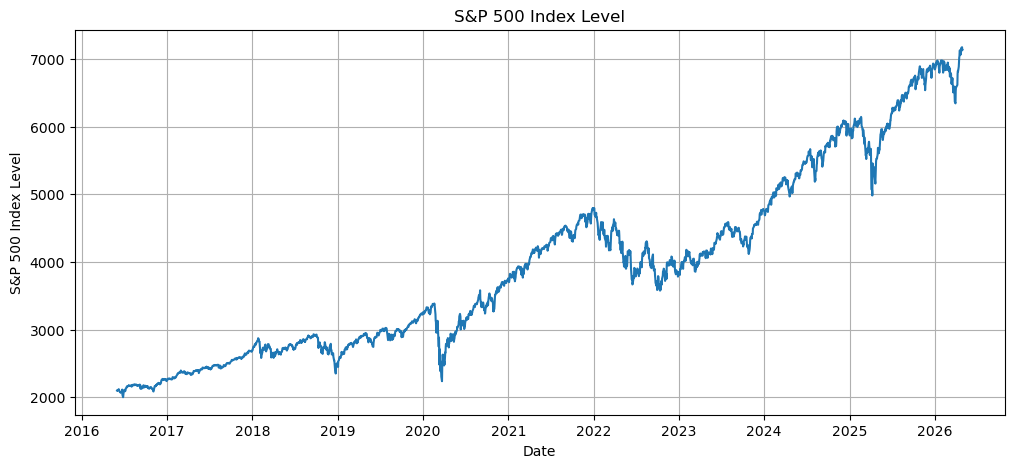

In [2]:
# Plot 1: S&P 500 Index Level

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sp500"])
plt.title("S&P 500 Index Level")
plt.xlabel("Date")
plt.ylabel("S&P 500 Index Level")
plt.grid(True)
plt.show()

### S&P 500 Index Level

This plot shows the raw S&P 500 daily closing level over time. The purpose of this plot is to inspect the long-run trend, large drawdowns, and recovery periods in the equity market. Because the raw index level trends over time, it is retained for reference but not used directly as the volatility forecasting target.

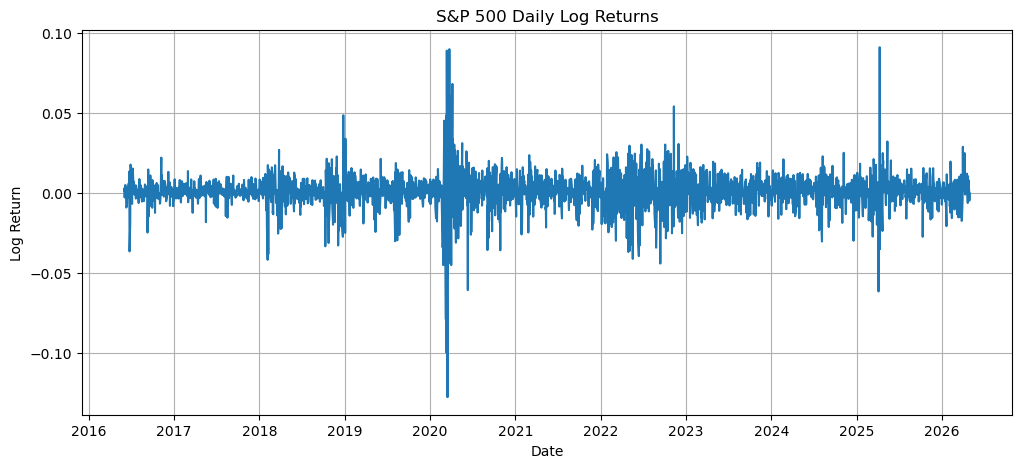

In [3]:
# Plot 2: S&P 500 Daily Log Returns

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sp500_log_return"])
plt.title("S&P 500 Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

### S&P 500 Daily Log Returns

This plot shows daily S&P 500 log returns. The purpose is to inspect return fluctuations and identify periods of unusually large positive or negative market movements. Clusters of large return movements may indicate volatility clustering, which would support the use of GARCH-style volatility models.

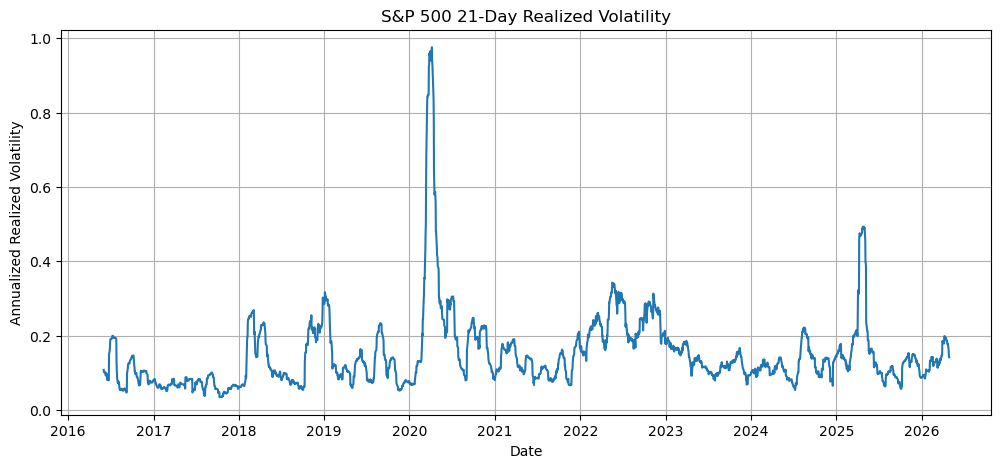

In [4]:
# Plot 3: S&P 500 21-Day Realized Volatility

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["sp500_realized_vol_21d"])
plt.title("S&P 500 21-Day Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Realized Volatility")
plt.grid(True)
plt.show()

### S&P 500 21-Day Realized Volatility

This plot shows the annualized 21-day realized volatility of S&P 500 log returns. This is the main forecasting target for the analysis. The purpose of this plot is to evaluate whether volatility appears persistent, clustered, or driven by major market stress periods.

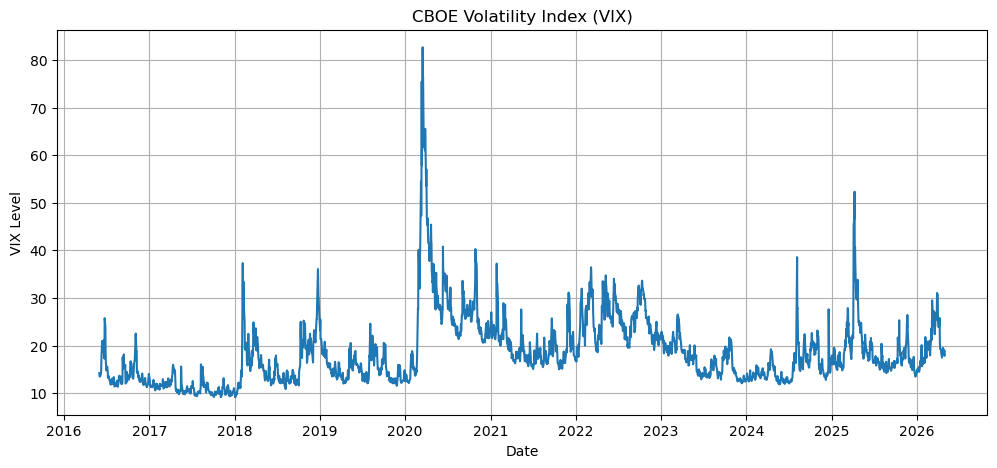

In [5]:
# Plot 4: VIX

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["vixcls"])
plt.title("CBOE Volatility Index (VIX)")
plt.xlabel("Date")
plt.ylabel("VIX Level")
plt.grid(True)
plt.show()

### VIX

This plot shows the VIX, which represents implied equity-market volatility. The purpose is to compare market expectations of volatility against realized S&P 500 volatility. Large VIX spikes generally correspond to periods of elevated market uncertainty.

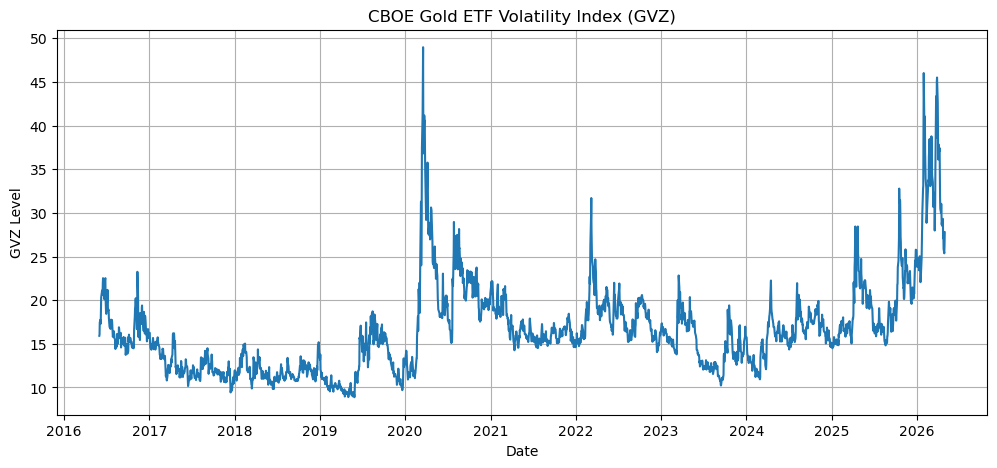

In [6]:
# Plot 5: GVZ

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["gvzcls"])
plt.title("CBOE Gold ETF Volatility Index (GVZ)")
plt.xlabel("Date")
plt.ylabel("GVZ Level")
plt.grid(True)
plt.show()

### GVZ

This plot shows the CBOE Gold ETF Volatility Index. GVZ is included as a cross-asset volatility indicator. The purpose is to inspect whether gold-market volatility exhibits spikes during broader market stress periods and whether it may provide useful information for forecasting equity-market realized volatility.

In [7]:
# Summary Statistics

summary_stats = df[
    ["sp500", "vixcls", "gvzcls", "sp500_log_return", "sp500_realized_vol_21d"]
].describe().T

# Add missing count for completeness
summary_stats["missing_values"] = df[
    ["sp500", "vixcls", "gvzcls", "sp500_log_return", "sp500_realized_vol_21d"]
].isna().sum()

display(summary_stats)

,count,mean,std,min,25%,50%,75%,max,missing_values
sp500,2492.0,3943.702588,1354.696889,2000.540000,2779.735000,3854.895000,4682.812500,7173.910000,0
vixcls,2492.0,18.574137,7.352972,9.140000,13.537500,16.870000,21.552500,82.690000,0
gvzcls,2492.0,16.557929,5.267199,8.880000,12.630000,15.830000,18.480000,48.980000,0
sp500_log_return,2492.0,0.000491,0.011441,-0.127652,-0.003641,0.000759,0.005792,0.090895,0
sp500_realized_vol_21d,2492.0,0.149674,0.104459,0.034688,0.088607,0.124002,0.183535,0.975552,0


### Summary Statistics Interpretation

The cleaned dataset contains 2,492 complete daily observations across all variables. Missing values are zero after the cleaning and merging process, confirming that the modeling dataset is complete for S&P 500, VIX, GVZ, S&P 500 log returns, and 21-day realized volatility.

The S&P 500 index level has a wide range over the sample period, reflecting the long-run upward trend in equity prices as well as major market drawdowns and recoveries. This supports the decision not to model the raw index level directly as the volatility target.

The S&P 500 daily log return has a mean close to zero, which is typical for daily return series, but it also shows large negative and positive extremes. These extremes are important because volatility models are designed to capture periods when market movements become unusually large.

The 21-day realized volatility series has a mean of roughly 0.15, or 15% annualized volatility, but reaches much higher levels during market stress periods. VIX and GVZ also show large maximum values relative to their medians, indicating that implied volatility can spike sharply during periods of market uncertainty.

,vixcls,gvzcls,sp500_log_return,sp500_realized_vol_21d
vixcls,1.000000,0.621690,-0.172186,0.815225
gvzcls,0.621690,1.000000,-0.022929,0.481326
sp500_log_return,-0.172186,-0.022929,1.000000,0.014567
sp500_realized_vol_21d,0.815225,0.481326,0.014567,1.000000


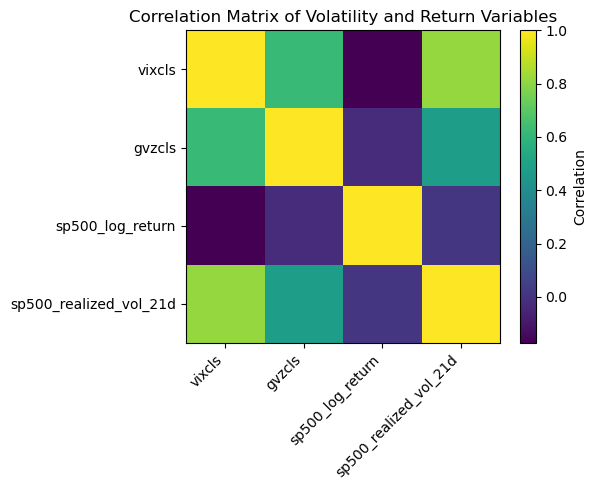

In [8]:
# Correlation Matrix

corr_vars = df[
    ["vixcls", "gvzcls", "sp500_log_return", "sp500_realized_vol_21d"]
]

corr_matrix = corr_vars.corr()

display(corr_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix of Volatility and Return Variables")
plt.tight_layout()
plt.show()

### Correlation Matrix Interpretation

The correlation matrix shows the relationships among VIX, GVZ, S&P 500 log returns, and S&P 500 21-day realized volatility. The strongest relationship is between VIX and realized volatility, with a correlation of approximately 0.82. This suggests that implied equity-market volatility is strongly associated with realized S&P 500 volatility and may be an important predictor in the forecasting models.

GVZ is also positively correlated with both VIX and realized S&P 500 volatility. Its correlation with VIX is approximately 0.62, while its correlation with realized volatility is approximately 0.48. This suggests that gold-market volatility tends to rise during broader uncertainty periods, but it is not perfectly redundant with equity-market volatility. Therefore, GVZ may provide useful cross-asset information in the Random Forest model.

S&P 500 log returns have weak correlations with the volatility variables. The correlation between log returns and VIX is negative, while the correlations with GVZ and realized volatility are close to zero. This is expected because daily returns measure market direction, while volatility measures the magnitude of market fluctuations. A market can be volatile during both positive and negative return periods, although equity-market volatility often rises during sharp negative-return episodes.

Overall, the correlation matrix supports the modeling design. VIX is likely to be the strongest volatility-related predictor, while GVZ may provide additional cross-market information. The low correlation between daily returns and realized volatility suggests that return direction alone is not enough to explain volatility behavior.

## Stationarity and Dependence Diagnostics

This section evaluates whether the transformed financial time-series variables show stationarity, autocorrelation, and volatility clustering. These diagnostics determine whether ARIMA and GARCH are appropriate modeling choices. ARIMA requires the target series to be stationary or differenced into stationarity, while GARCH is motivated when returns show volatility clustering or autocorrelation in squared returns.
- The diagnostic plots and tests are used to determine whether ARIMA and GARCH are appropriate for the volatility forecasting task.

- The ACF/PACF plots for S&P 500 log returns help determine whether daily returns contain meaningful linear autocorrelation. The ACF/PACF plots for squared log returns are especially important for GARCH because volatility clustering may appear even when raw returns show little autocorrelation.

- The ACF/PACF plots for 21-day realized volatility show whether realized volatility is persistent over time. Strong persistence would support ARIMA-style forecasting because the target variable depends on its own past values.

- The ADF and KPSS tests provide formal evidence about stationarity. ADF tests the null hypothesis of nonstationarity, while KPSS tests the null hypothesis of stationarity. Because financial volatility series can be persistent, both tests are interpreted together rather than relying on only one result.

- The ARCH LM test evaluates whether S&P 500 log returns contain conditional heteroskedasticity. A statistically significant ARCH test would support the use of GARCH because it indicates that return volatility depends on past volatility behavior.

## ACF & PACF Plots 

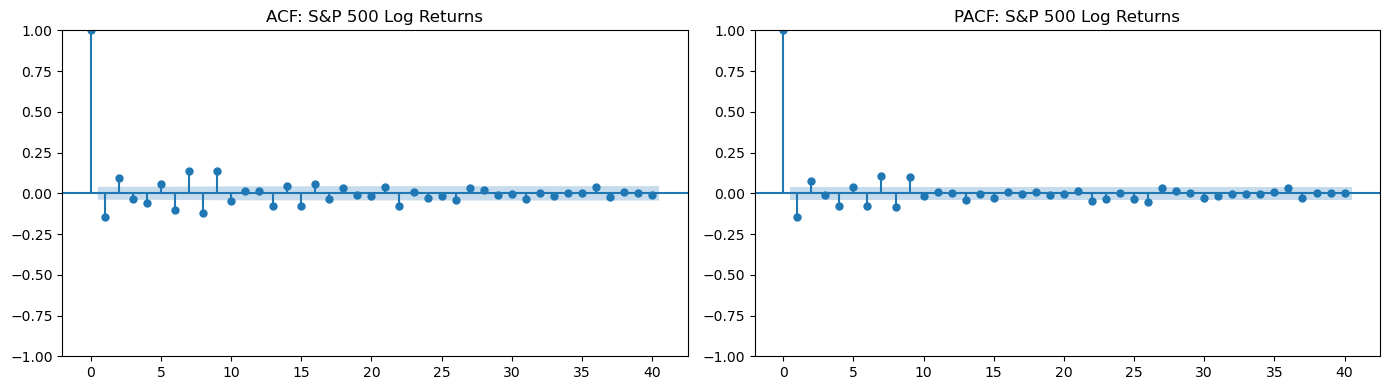

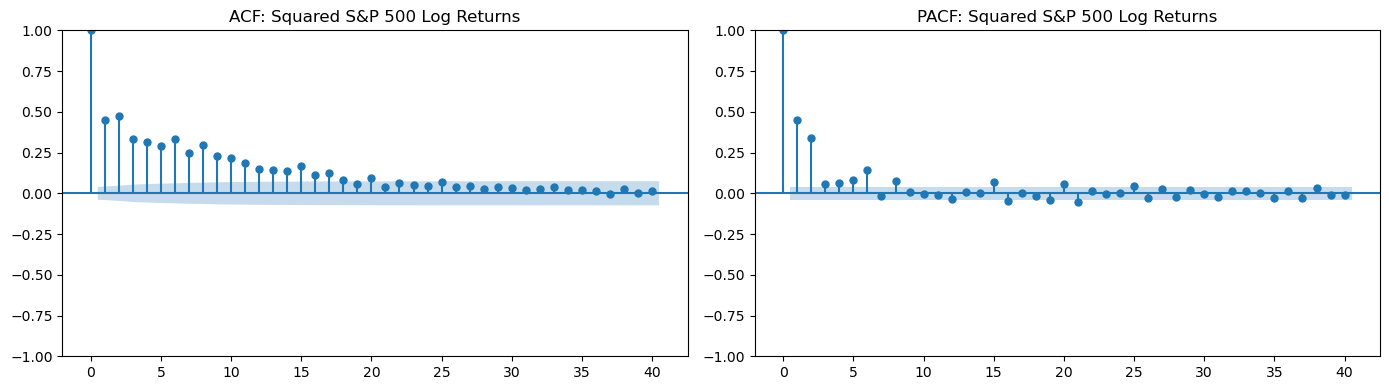

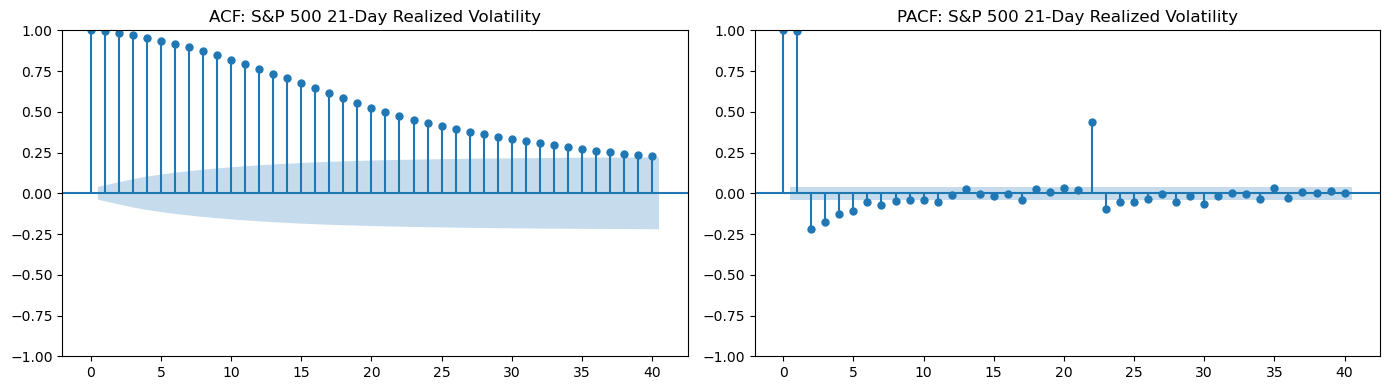

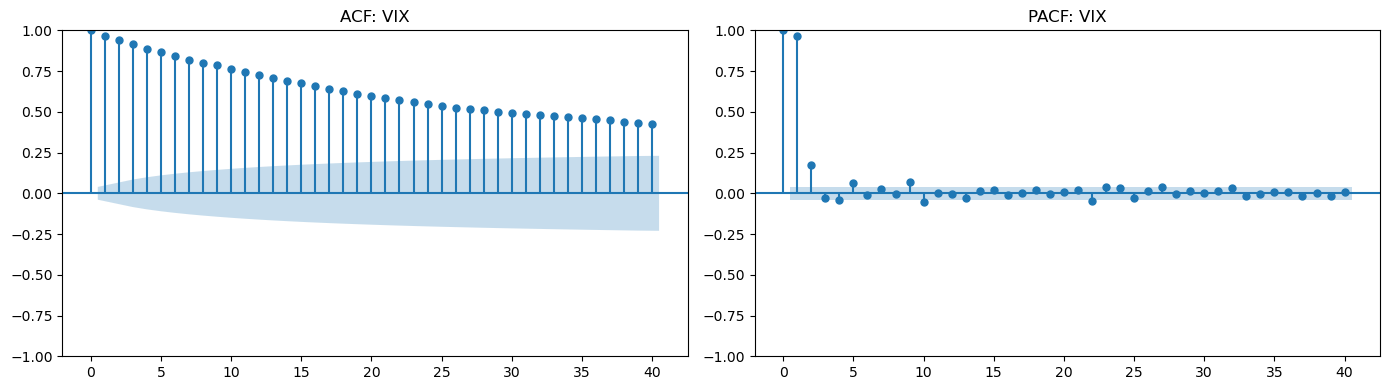

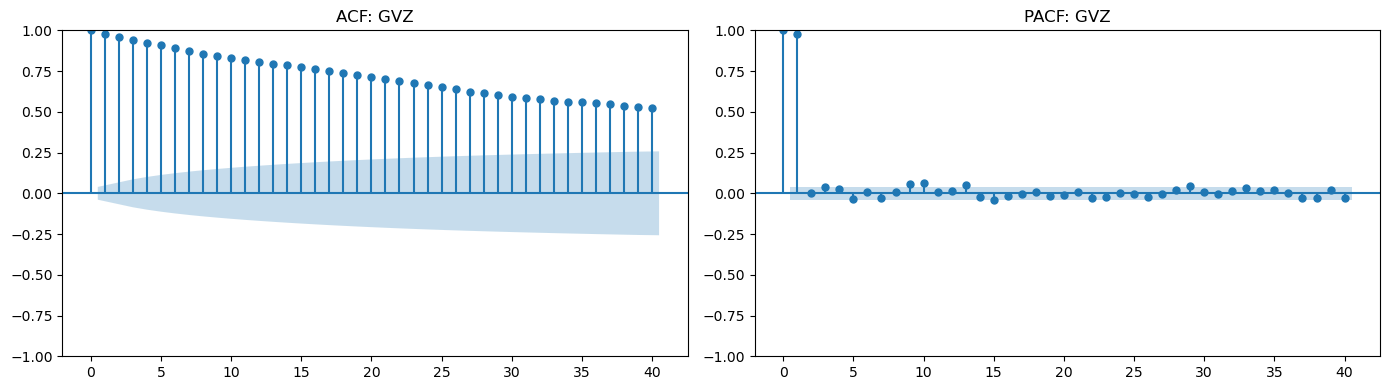

In [9]:
# Stationarity and Dependence Diagnostics
# ACF and PACF plots

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

series_dict = {
    "S&P 500 Log Returns": df["sp500_log_return"],
    "Squared S&P 500 Log Returns": df["sp500_log_return"] ** 2,
    "S&P 500 21-Day Realized Volatility": df["sp500_realized_vol_21d"],
    "VIX": df["vixcls"],
    "GVZ": df["gvzcls"]
}

for title, series in series_dict.items():
    clean_series = series.dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    plot_acf(clean_series, lags=40, ax=axes[0])
    axes[0].set_title(f"ACF: {title}")

    plot_pacf(clean_series, lags=40, method="ywm", ax=axes[1])
    axes[1].set_title(f"PACF: {title}")

    plt.tight_layout()
    plt.show()

### ACF and PACF Interpretation

The ACF and PACF plots were used to evaluate temporal dependence before fitting the forecasting models. The ACF measures the overall correlation between a series and its own lagged values. The PACF measures the direct relationship between the current value and a specific lag after accounting for the shorter lags in between. In this analysis, ACF is used to evaluate broad persistence, while PACF is used to inspect direct lag structure.

The PACF plots were estimated using the Yule-Walker modified method. This is a standard method for estimating partial autocorrelations and is connected to autoregressive modeling. The method is used here only for diagnostic plotting, not as a final forecasting model. Specifying the PACF method also makes the diagnostic process explicit and reproducible. Including PACF is useful because ACF alone shows broad persistence, while PACF helps identify whether specific lags contribute unique information after earlier lags have already been considered.

The S&P 500 log return series shows weak linear autocorrelation. Most ACF and PACF values fall close to zero after the earliest lags, suggesting that daily return direction is not strongly predictable from its own recent history using a simple linear autocorrelation structure. This pattern is common in daily financial returns and supports using returns rather than raw S&P 500 price levels for volatility modeling.

The squared S&P 500 log returns were computed temporarily for diagnostic purposes. Squaring returns removes direction and emphasizes the magnitude of market movement: a large negative return and a large positive return both become large positive values after squaring. This makes squared returns useful for detecting volatility clustering. The ACF of squared returns shows stronger positive autocorrelation that decays across multiple lags, meaning large market movements tend to cluster together over time. This is the main diagnostic evidence supporting the use of GARCH-family models because GARCH is designed to model time-varying conditional variance.

The S&P 500 21-day realized volatility series shows slow ACF decay, indicating strong persistence. Persistence means sustained autocorrelation across multiple lags. In this case, high realized volatility tends to be followed by high realized volatility, and low realized volatility tends to be followed by low realized volatility. This supports ARIMA-style forecasting because the target variable contains useful information in its own past values. The PACF shows strong early lag effects and visible structure near the 21-day region, which is expected because the realized-volatility target is constructed from a 21-trading-day rolling window. Adjacent observations share many of the same underlying return observations.

The VIX also shows slow ACF decay, indicating that implied equity-market volatility is persistent. This means volatility expectations tend to remain elevated or depressed for stretches of time rather than moving randomly each day. GVZ shows a similar persistence pattern, suggesting that gold-market volatility also depends on its own recent history. These patterns support including lagged VIX and lagged GVZ as candidate predictors in ARIMAX and Random Forest models. However, visual persistence alone does not prove predictive usefulness; the variables must improve out-of-sample forecasting performance to be considered useful predictors.

Overall, the ACF and PACF diagnostics support the planned modeling strategy. ARIMA is appropriate as a univariate benchmark for the persistent 21-day realized-volatility target. ARIMAX is appropriate as an extension because VIX and GVZ are persistent external volatility indicators that may improve forecasts of realized S&P 500 volatility. GARCH is appropriate because squared returns show volatility clustering. Random Forest is appropriate as a nonlinear benchmark using lagged realized volatility, lagged VIX, lagged GVZ, and lagged returns as predictors. The diagnostics justify the selected models, but the final comparison must be based on out-of-sample forecast performance.

The models are not applied identically to every variable. The primary target is S&P 500 21-day realized volatility. ARIMA forecasts this target using its own past values. ARIMAX forecasts the same target while adding external predictors such as VIX and GVZ. GARCH and EGARCH are fit to S&P 500 log returns because they model the conditional variance of returns. Random Forest uses lagged versions of realized volatility, VIX, GVZ, and S&P 500 returns to test whether nonlinear and cross-market information improves forecasts of realized volatility.

## Stationarity Tests: ADF and KPSS 

In [10]:
# Stationarity Tests: ADF and KPSS

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
import pandas as pd
import warnings

def stationarity_tests(series, series_name):
    """
    Run ADF and KPSS stationarity tests.

    ADF null hypothesis:
        The series has a unit root / is nonstationary.

    KPSS null hypothesis:
        The series is stationary.
    """
    clean_series = series.dropna()

    # ADF test
    adf_result = adfuller(clean_series, autolag="AIC")

    # KPSS test
    # InterpolationWarning is suppressed because KPSS p-values are table-bounded.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        kpss_result = kpss(clean_series, regression="c", nlags="auto")

    results = {
        "series": series_name,
        "adf_stat": adf_result[0],
        "adf_pvalue": adf_result[1],
        "kpss_stat": kpss_result[0],
        "kpss_pvalue": kpss_result[1],
    }

    return results

test_results = []

test_results.append(stationarity_tests(df["sp500_log_return"], "S&P 500 Log Returns"))
test_results.append(stationarity_tests(df["sp500_realized_vol_21d"], "S&P 500 21-Day Realized Volatility"))
test_results.append(stationarity_tests(df["vixcls"], "VIX"))
test_results.append(stationarity_tests(df["gvzcls"], "GVZ"))

stationarity_results = pd.DataFrame(test_results)

# Add plain-English decision columns
stationarity_results["adf_interpretation"] = stationarity_results["adf_pvalue"].apply(
    lambda p: "Reject nonstationarity" if p < 0.05 else "Fail to reject nonstationarity"
)

stationarity_results["kpss_interpretation"] = stationarity_results["kpss_pvalue"].apply(
    lambda p: "Reject stationarity" if p < 0.05 else "Fail to reject stationarity"
)

display(stationarity_results)

,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue,adf_interpretation,kpss_interpretation
0,S&P 500 Log Returns,-15.820521,1.021437e-28,0.029324,0.100000,Reject nonstationarity,Fail to reject stationarity
1,S&P 500 21-Day Realized Volatility,-5.075334,1.571155e-05,0.405519,0.074776,Reject nonstationarity,Fail to reject stationarity
2,VIX,-5.261455,6.577475e-06,0.975086,0.010000,Reject nonstationarity,Reject stationarity
3,GVZ,-3.595390,5.849783e-03,1.948474,0.010000,Reject nonstationarity,Reject stationarity


### Stationarity Test Interpretation

The stationarity tests evaluate whether the series are appropriate for time-series modeling in their current form. Two tests were used because they have opposite null hypotheses. The Augmented Dickey-Fuller test evaluates whether a series has a unit root, so a low ADF p-value supports rejecting nonstationarity. The KPSS test evaluates whether a series is stationary, so a low KPSS p-value supports rejecting stationarity.

At the 5% significance level, the S&P 500 log return series shows strong evidence of stationarity. The ADF test rejects nonstationarity, and the KPSS test fails to reject stationarity. This supports using log returns rather than raw S&P 500 price levels for volatility modeling and supports the use of GARCH-family models on the return series.

The S&P 500 21-day realized volatility series also appears usable for ARIMA-style modeling. The ADF test rejects nonstationarity, while the KPSS test fails to reject stationarity at the 5% level. However, the ACF plots showed that realized volatility is highly persistent. This means the series contains strong dependence on its own past values, which supports ARIMA and ARIMAX forecasting of realized volatility.

The VIX and GVZ results are mixed. For both volatility indexes, the ADF test rejects nonstationarity, but the KPSS test rejects stationarity. This type of conflict can occur because ADF and KPSS test opposite null hypotheses and because persistent time series may not be cleanly classified by one test alone. The result suggests that VIX and GVZ should be treated as persistent volatility-index series rather than simple white-noise-like stationary series.

This does not make VIX or GVZ unusable. In this notebook, they are not treated as primary ARIMA targets. Instead, they are used as external predictors in ARIMAX and as lagged predictors in Random Forest. Their value will be judged by whether they improve out-of-sample forecasts of S&P 500 realized volatility.

Overall, the stationarity tests support the planned modeling sequence. S&P 500 log returns are suitable for GARCH-family modeling, S&P 500 realized volatility is suitable as the main ARIMA/ARIMAX forecasting target, and VIX and GVZ are retained as persistent external predictors whose usefulness will be evaluated through forecast performance.

#### Reference Note
 The ADF and KPSS interpretation follows standard stationarity-testing guidance: ADF tests the null hypothesis of a unit root, while KPSS tests the null hypothesis of stationarity. Because the tests use opposite null hypotheses, conflicting results are interpreted cautiously.

## ARCH LM Test

In [11]:
# ARCH Effect Test

from statsmodels.stats.diagnostic import het_arch
import pandas as pd

returns = df["sp500_log_return"].dropna()

arch_test = het_arch(returns, nlags=12)

arch_results = pd.DataFrame({
    "test": ["ARCH LM Test"],
    "lags": [12],
    "lm_stat": [arch_test[0]],
    "lm_pvalue": [arch_test[1]],
    "f_stat": [arch_test[2]],
    "f_pvalue": [arch_test[3]]
})

display(arch_results)

,test,lags,lm_stat,lm_pvalue,f_stat,f_pvalue
0,ARCH LM Test,12,804.580922,1.723487e-164,98.726599,6.937222e-200


### ARCH LM Test Interpretation

The ARCH LM test was run to determine whether the S&P 500 log return series contains conditional heteroskedasticity. This diagnostic is important because GARCH-family models are designed for series whose volatility changes over time and depends on past shocks or past volatility. Before fitting GARCH or EGARCH, the return series should show evidence that volatility is not constant.

The null hypothesis of the ARCH LM test is that there are no ARCH effects, meaning the conditional variance is constant and past return shocks do not help explain current volatility. The alternative hypothesis is that ARCH effects are present, meaning volatility depends on past return behavior.

The ARCH LM test used 12 lags to evaluate short-run volatility dependence without over-parameterizing the diagnostic regression. The ARCH LM test result is statistically significant. The LM p-value is approximately **1.72 × 10⁻¹⁶⁴**, and the F-test p-value is approximately **6.94 × 10⁻²⁰⁰**, both far below the 5% significance level. Therefore, the null hypothesis of no ARCH effects is rejected.

This result provides strong evidence of conditional heteroskedasticity in S&P 500 log returns. This does not need to be removed before modeling; instead, it is the behavior that GARCH-family models are designed to capture. In practical terms, volatility is not constant through time. Periods of large market movements tend to cluster together, and calmer periods tend to cluster together. This supports the earlier ACF/PACF finding that squared returns are autocorrelated.

Because the ARCH LM test confirms volatility clustering statistically, GARCH and EGARCH are justified for the modeling stage. The next step is to create a chronological train/test split and compare ARIMA, ARIMAX, GARCH/EGARCH, and Random Forest using out-of-sample forecast accuracy.

## Train/Test Split and Forecast Evaluation Setup

The modeling stage uses a chronological train/test split rather than a random split. This is necessary because time-series observations are ordered, and randomly shuffling observations would allow future information to influence the training process. The training set is used to fit each model, while the test set is held out for out-of-sample forecast evaluation.

The primary target variable is `sp500_realized_vol_21d`, which represents annualized S&P 500 realized volatility over the prior 21 trading days. ARIMA and ARIMAX forecast this target directly. GARCH and EGARCH are fit to S&P 500 log returns and then evaluated by comparing their volatility forecasts against realized volatility. Random Forest uses lagged realized volatility, lagged VIX, lagged GVZ, and lagged returns to forecast future realized volatility.

Forecast accuracy will be evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). MAE measures the average absolute forecast error, while RMSE penalizes larger errors more heavily. Lower values indicate better forecast accuracy.

Training set:
Rows: 1993
Date range: 2016-06-01 00:00:00 to 2024-05-01 00:00:00

Testing set:
Rows: 499
Date range: 2024-05-02 00:00:00 to 2026-04-29 00:00:00


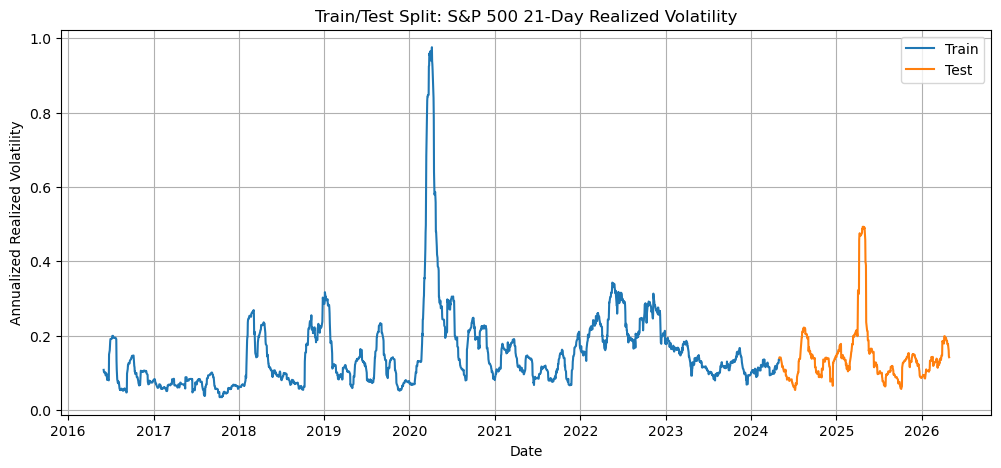

In [12]:
# Train/Test Split and Forecast Evaluation Setup

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define target variable
target_col = "sp500_realized_vol_21d"

# Chronological train/test split
# Use 80% training and 20% testing
split_idx = int(len(df) * 0.80)

train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

print("Training set:")
print("Rows:", len(train))
print("Date range:", train["date"].min(), "to", train["date"].max())

print("\nTesting set:")
print("Rows:", len(test))
print("Date range:", test["date"].min(), "to", test["date"].max())

# Forecast evaluation function
def evaluate_forecast(y_true, y_pred, model_name):
    """
    Evaluate forecast accuracy using MAE and RMSE.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse
    }

# Plot train/test split for target variable
plt.figure(figsize=(12, 5))
plt.plot(train["date"], train[target_col], label="Train")
plt.plot(test["date"], test[target_col], label="Test")
plt.title("Train/Test Split: S&P 500 21-Day Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Realized Volatility")
plt.legend()
plt.grid(True)
plt.show()

### Train/Test Split Interpretation

The dataset was split chronologically into an 80% training period and a 20% testing period. The training set contains 1,993 observations from June 2016 through May 2024, while the testing set contains 499 observations from May 2024 through April 2026.

A chronological split is used because time-series observations are ordered. Randomly shuffling observations would create look-ahead leakage by allowing future information to influence model training. The test period occurs entirely after the training period, so forecast accuracy is evaluated on future observations that were not used to estimate the models.

The testing period includes a visible volatility spike, which provides a useful out-of-sample stress episode for evaluating model performance. Models will be compared based on how accurately they forecast S&P 500 21-day realized volatility during this held-out period.

## Model 1: ARIMA Forecasting of S&P 500 Realized Volatility

The first forecasting model is ARIMA, which is used as a classical univariate benchmark. ARIMA forecasts the target variable using only its own past values and past forecast errors. In this analysis, the target is `sp500_realized_vol_21d`, the 21-day annualized realized volatility of S&P 500 log returns.

ARIMA is appropriate as a baseline because the diagnostic plots showed that realized volatility is persistent over time. This means past realized volatility contains useful information about future realized volatility. The ARIMA model does not use VIX or GVZ; those external volatility indicators are introduced later in ARIMAX and Random Forest.

A small grid search is used to compare candidate ARIMA orders based on AIC. The selected model is then fit on the training period and used to forecast the testing period. Forecast accuracy is evaluated using MAE and RMSE.

In [13]:
# Model 1: ARIMA Forecasting of S&P 500 21-Day Realized Volatility

import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

target_col = "sp500_realized_vol_21d"

y_train = train[target_col].astype(float)
y_test = test[target_col].astype(float)

# Since stationarity tests supported realized volatility as usable without differencing,
# start with d = 0 and include a constant term.
p_values = range(0, 5)
d_values = [0] # Do not differentiate series based on 
q_values = range(0, 5)

arima_results = []

warnings.filterwarnings("ignore")

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = SARIMAX(
            y_train,
            order=(p, d, q),
            trend="c",  # include constant/intercept
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        fitted_model = model.fit(disp=False)
        
        arima_results.append({
            "order": (p, d, q),
            "trend": "constant",
            "aic": fitted_model.aic,
            "bic": fitted_model.bic
        })
        
    except Exception:
        continue

arima_results_df = pd.DataFrame(arima_results).sort_values("aic").reset_index(drop=True)

print("Top ARIMA candidate models by AIC:")
display(arima_results_df.head(10))

best_arima_order = arima_results_df.loc[0, "order"]
print("Best ARIMA order selected by AIC:", best_arima_order)

final_arima_model = SARIMAX(
    y_train,
    order=best_arima_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_arima_fit = final_arima_model.fit(disp=False)

print(final_arima_fit.summary())

Top ARIMA candidate models by AIC:


,order,trend,aic,bic
0,"(2, 0, 1)",constant,-12219.953560,-12191.971599
1,"(3, 0, 2)",constant,-12215.545811,-12176.374581
2,"(3, 0, 3)",constant,-12207.403438,-12162.640340
3,"(4, 0, 3)",constant,-12204.707526,-12154.349040
4,"(2, 0, 2)",constant,-12204.439821,-12170.864481
5,"(3, 0, 4)",constant,-12201.857489,-12151.503529
6,"(4, 0, 4)",constant,-12196.192427,-12140.243583
7,"(4, 0, 2)",constant,-12179.669769,-12134.906671
8,"(3, 0, 1)",constant,-12174.964383,-12141.389043
9,"(4, 0, 0)",constant,-12161.644409,-12128.072086


Best ARIMA order selected by AIC: (2, 0, 1)
                                 SARIMAX Results                                  
Dep. Variable:     sp500_realized_vol_21d   No. Observations:                 1993
Model:                   SARIMAX(2, 0, 1)   Log Likelihood                6114.977
Date:                    Sat, 02 May 2026   AIC                         -12219.954
Time:                            14:12:46   BIC                         -12191.972
Sample:                                 0   HQIC                        -12209.677
                                   - 1993                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0005   9.69e-05      5.451      0.000       0.000       0.001
ar.L1          1.9151      0.009    215.757      0.000 

### ARIMA Model Selection Interpretation

The ARIMA model was used as the first univariate benchmark for forecasting S&P 500 21-day realized volatility. This model uses only the past behavior of realized volatility and past forecast errors, without including external predictors such as VIX or GVZ. This makes ARIMA a useful baseline for evaluating how much forecast accuracy can be achieved from the persistence of realized volatility alone.

The model was estimated using the `SARIMAX` function from `statsmodels`. Although the class name is SARIMAX, the model estimated here is an ARIMA model because no seasonal order and no exogenous variables were included. The model was specified with a constant term so that forecasts could revert toward a positive long-run volatility level rather than collapsing toward zero.

The final ARIMA grid search fixed `d = 0` because the stationarity diagnostics supported using the realized-volatility target without differencing. The ADF test rejected nonstationarity, and the KPSS test failed to reject stationarity at the 5% level. Forcing `d = 1` would difference a series that does not clearly require differencing, which could remove useful persistence from the volatility target and make the forecast less interpretable.

Candidate AR and MA orders from 0 to 4 were compared using AIC. This range allows the model search to compare simple low-order ARIMA specifications while avoiding unnecessary high-order models that may overfit the training data. Candidate ARIMA models were evaluated after the stationarity diagnostics, and because the realized-volatility target did not require differencing under the ADF/KPSS results, the final ARIMA search fixed `d = 0` and selected among autoregressive and moving-average orders using AIC.

The selected model was ARIMA(2, 0, 1) with a constant. This means the model uses two autoregressive lags, no differencing, and one moving-average error term. The selected order is consistent with the earlier diagnostics showing that realized volatility is persistent and contains useful information in its own recent history.

The estimated AR and MA coefficients are statistically significant, which suggests that both recent realized-volatility values and recent forecast errors contribute to the model. The first autoregressive coefficient is positive and large, supporting the persistence observed in the ACF plots. The second autoregressive coefficient and moving-average term help adjust the short-run dynamics of the volatility process.

The Ljung-Box test p-value is above the 5% significance level, suggesting that the fitted ARIMA model does not leave strong residual autocorrelation at the tested lag. This is a useful diagnostic because it indicates that the model captured much of the linear dependence in the realized-volatility series. The Jarque-Bera statistic is large and the residual kurtosis is high, indicating non-normal and heavy-tailed residual behavior. This is common in financial volatility modeling and suggests that ARIMA is a useful baseline but may not fully capture extreme volatility behavior.

Overall, the ARIMA(2, 0, 1) model with a constant is a reasonable univariate benchmark. It captures persistence in realized volatility, but it does not include external volatility indicators or nonlinear effects. The next models test whether VIX, GVZ, conditional variance modeling, or nonlinear lagged features improve forecast accuracy beyond this ARIMA baseline.

### ARIMA Residual Diagnostics

After fitting the ARIMA model, residual diagnostics are used to evaluate whether the model captured the main linear dependence in the realized-volatility series. A good ARIMA fit should leave residuals that do not show strong remaining autocorrelation. The residual time plot checks whether errors are centered around zero over time. The residual ACF checks whether forecast errors remain correlated across lags. The Q-Q plot checks whether residuals are approximately normal, although financial volatility residuals often show heavy tails.

These diagnostics do not determine whether ARIMA is the best model overall. They evaluate whether the ARIMA baseline is internally reasonable before comparing it against ARIMAX, GARCH/EGARCH, and Random Forest.

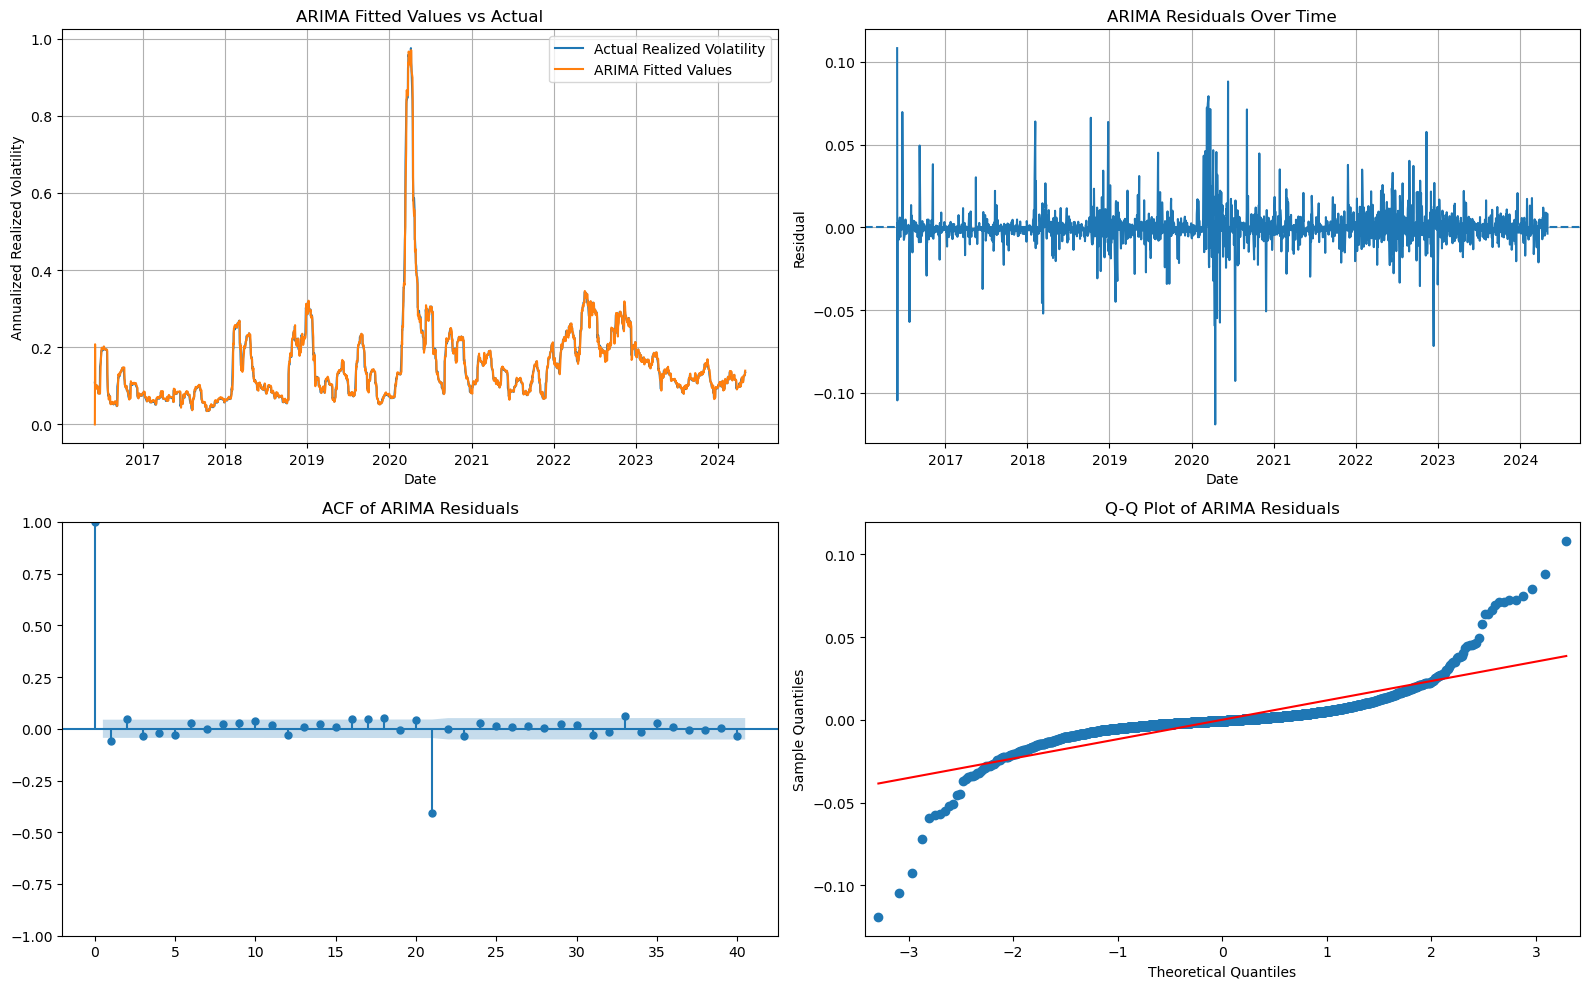

,lb_stat,lb_pvalue
10,23.241772,9.888491e-03
20,45.272292,1.013392e-03
30,389.596778,3.516643e-64


In [14]:
# ARIMA Residual Diagnostics 

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import pandas as pd

# Extract fitted values and residuals
arima_fitted = final_arima_fit.fittedvalues
arima_residuals = final_arima_fit.resid

# Align with training dates
arima_diag = pd.DataFrame({
    "date": train.loc[arima_residuals.index, "date"],
    "actual": y_train.loc[arima_residuals.index],
    "fitted": arima_fitted,
    "residual": arima_residuals
}).dropna()

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Actual vs fitted
axes[0, 0].plot(arima_diag["date"], arima_diag["actual"], label="Actual Realized Volatility")
axes[0, 0].plot(arima_diag["date"], arima_diag["fitted"], label="ARIMA Fitted Values")
axes[0, 0].set_title("ARIMA Fitted Values vs Actual")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Annualized Realized Volatility")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Residuals over time
axes[0, 1].plot(arima_diag["date"], arima_diag["residual"])
axes[0, 1].axhline(0, linestyle="--")
axes[0, 1].set_title("ARIMA Residuals Over Time")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Residual")
axes[0, 1].grid(True)

# ACF of residuals
plot_acf(arima_diag["residual"], lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF of ARIMA Residuals")

# Q-Q plot
qqplot(arima_diag["residual"], line="s", ax=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of ARIMA Residuals")

plt.tight_layout()
plt.show()

# Ljung-Box test table
ljung_box_results = acorr_ljungbox(
    arima_diag["residual"],
    lags=[10, 20, 30],
    return_df=True
)

display(ljung_box_results)

### ARIMA Residual Diagnostics Interpretation

The residual diagnostics suggest that the ARIMA model is a reasonable univariate baseline for forecasting S&P 500 realized volatility. The fitted-values plot shows that the model captures the general level and persistence of realized volatility, although it does not fully reproduce extreme volatility spikes.

The residual time-series plot shows that residuals are centered around zero, but larger residuals appear during stress periods, especially around major volatility episodes. This indicates that the ARIMA model captures much of the systematic linear structure in the series but leaves some large shocks unexplained.

The ACF of the residuals shows that most residual autocorrelations lie close to zero and within the confidence bands, suggesting that the model has removed most of the remaining linear serial dependence. This supports the use of ARIMA as a baseline model.

The Q-Q plot indicates that the residuals are not normally distributed and exhibit heavy tails. This is common in financial volatility data and suggests that extreme market movements are not fully captured by a simple ARIMA specification.

Overall, the residual diagnostics support keeping ARIMA as the baseline benchmark, while also motivating the use of more advanced models such as ARIMAX, GARCH/EGARCH, and Random Forest to improve forecasting performance during volatile periods.

### ARIMA Rolling One-Step-Ahead Forecast

The ARIMA forecast is evaluated using a rolling one-step-ahead forecasting procedure. This approach is more realistic for daily financial forecasting than a fixed-origin multi-step forecast because the model is updated as new test-period observations become available.

At each point in the test period, the model forecasts the next day’s S&P 500 realized volatility using information available up to that date. After the actual observation is observed, it is added to the model history before producing the next forecast. This preserves the time ordering of the data while avoiding look-ahead leakage.

This procedure evaluates how ARIMA would perform in an operational forecasting setting where volatility forecasts are updated daily. Forecast accuracy is evaluated using MAE and RMSE, and forecast uncertainty is shown using 95% prediction intervals.

,model,order,trend,MAE,RMSE
0,ARIMA Rolling One-Step,"(2, 0, 1)",constant,0.006124,0.013154


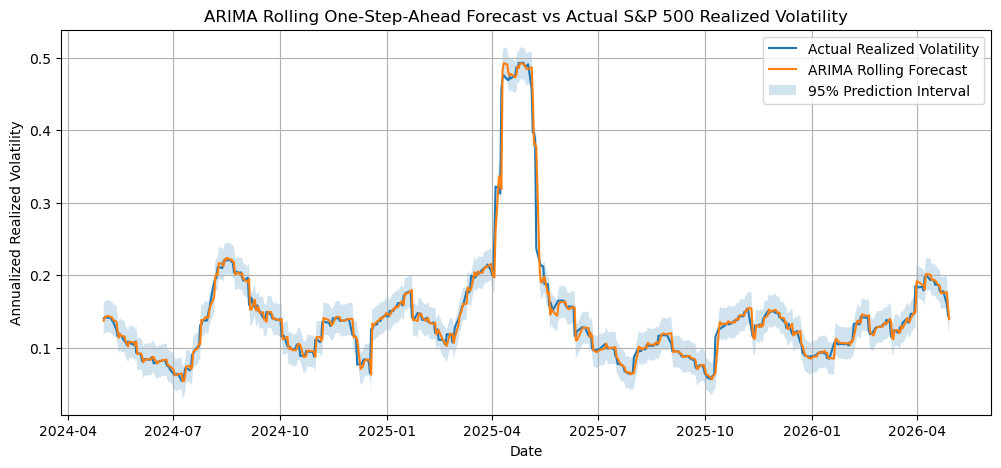

In [15]:
# ARIMA Rolling One-Step-Ahead Forecast with Prediction Intervals

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

rolling_results = final_arima_fit

rolling_forecasts = []
rolling_lower = []
rolling_upper = []

for idx, actual_value in y_test.items():

    # One-step-ahead forecast
    forecast_obj = rolling_results.get_forecast(steps=1)
    forecast_mean = forecast_obj.predicted_mean.iloc[0]
    forecast_ci = forecast_obj.conf_int(alpha=0.05).iloc[0]

    rolling_forecasts.append(forecast_mean)
    rolling_lower.append(forecast_ci.iloc[0])
    rolling_upper.append(forecast_ci.iloc[1])

    # IMPORTANT:
    # The appended observation must match the original endogenous series name.
    new_observation = pd.Series(
        [actual_value],
        index=[idx],
        name=y_train.name
    )

    rolling_results = rolling_results.append(
        new_observation,
        refit=False
    )

# Convert forecasts to Series aligned with the test set
arima_rolling_forecast = pd.Series(
    rolling_forecasts,
    index=test.index,
    name="arima_rolling_forecast"
)

arima_rolling_lower = pd.Series(
    rolling_lower,
    index=test.index,
    name="arima_rolling_lower"
)

arima_rolling_upper = pd.Series(
    rolling_upper,
    index=test.index,
    name="arima_rolling_upper"
)

# Evaluate rolling forecast
arima_rolling_mae = mean_absolute_error(y_test, arima_rolling_forecast)
arima_rolling_rmse = np.sqrt(mean_squared_error(y_test, arima_rolling_forecast))

arima_eval = pd.DataFrame({
    "model": ["ARIMA Rolling One-Step"],
    "order": [best_arima_order],
    "trend": ["constant"],
    "MAE": [arima_rolling_mae],
    "RMSE": [arima_rolling_rmse]
})

display(arima_eval)

# Plot actual vs rolling forecast with 95% prediction interval
plt.figure(figsize=(12, 5))
plt.plot(test["date"], y_test, label="Actual Realized Volatility")
plt.plot(test["date"], arima_rolling_forecast, label="ARIMA Rolling Forecast")
plt.fill_between(
    test["date"],
    arima_rolling_lower,
    arima_rolling_upper,
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.title("ARIMA Rolling One-Step-Ahead Forecast vs Actual S&P 500 Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Realized Volatility")
plt.legend()
plt.grid(True)
plt.show()

### ARIMA Rolling Forecast Interpretation

The ARIMA rolling one-step-ahead forecast provides the final ARIMA benchmark for the model comparison. Unlike the fixed-origin forecast, which forecasts the entire test period from one starting point, the rolling forecast updates the model history after each new test-period observation becomes available. This produces a more realistic daily forecasting setup while preserving temporal order and avoiding look-ahead leakage.

The rolling ARIMA forecast tracks the realized-volatility path much more closely than the fixed-origin forecast. This occurs because the model is repeatedly updated with newly observed realized-volatility values, allowing it to adjust to changing volatility conditions over the test period. The forecast captures the general rise and fall of realized volatility, including much of the large volatility spike in 2025.

The model produced an MAE of approximately **0.0061** and an RMSE of approximately **0.0132** on the testing period. These errors are substantially lower than the fixed-origin ARIMA forecast, showing that ARIMA performs much better when forecasts are updated sequentially. The RMSE remains larger than the MAE because larger errors during sharper volatility movements receive more penalty.

The 95% prediction interval generally surrounds the realized-volatility path, but the model can still lag around abrupt turning points. This is expected because ARIMA remains a univariate model: it uses only past realized volatility and past forecast errors, without external predictors such as VIX or GVZ.

Overall, the rolling ARIMA model is a strong univariate benchmark. It shows that realized volatility contains substantial information in its own recent history. The next models test whether adding external volatility indicators through ARIMAX, modeling conditional variance through GARCH/EGARCH, or using nonlinear lagged features through Random Forest improves forecast accuracy beyond this ARIMA baseline.

## Model 2: ARIMAX Forecasting with VIX and GVZ

The second forecasting model is ARIMAX, which extends the ARIMA baseline by adding external volatility indicators. The target variable remains `sp500_realized_vol_21d`, but the model now includes VIX and GVZ as exogenous predictors.

This model tests whether implied equity-market volatility and gold-market volatility improve forecasts of realized S&P 500 volatility beyond what can be explained by the target’s own past values. VIX represents implied equity-market volatility, while GVZ represents gold-market volatility. If ARIMAX improves forecast accuracy relative to ARIMA, this would suggest that external volatility indicators add useful information for forecasting realized equity-market volatility.

To avoid look-ahead leakage, the exogenous variables are lagged by one trading day. This means the model uses yesterday’s VIX and GVZ values to forecast today’s realized volatility. The ARIMA order is kept consistent with the selected ARIMA benchmark, ARIMA(2, 0, 1), so that the main difference between the two models is the addition of external predictors.`

In [16]:
# Model 2: ARIMAX Forecasting with VIX and GVZ

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Copy dataframe to create ARIMAX features
arimax_df = df.copy()

# Create lagged exogenous predictors to avoid look-ahead leakage
# Uses yesterday's VIX and GVZ to forecast today's S&P 500 realized volatility
arimax_df["vix_lag1"] = arimax_df["vixcls"].shift(1)
arimax_df["gvz_lag1"] = arimax_df["gvzcls"].shift(1)

# Drop rows with missing values caused by lagging
arimax_df = arimax_df.dropna(
    subset=["sp500_realized_vol_21d", "vix_lag1", "gvz_lag1"]
).copy()

# Reset index so statsmodels append works cleanly during rolling forecasts later
arimax_df = arimax_df.reset_index(drop=True)

# Chronological train/test split
split_idx_arimax = int(len(arimax_df) * 0.80)

arimax_train = arimax_df.iloc[:split_idx_arimax].copy()
arimax_test = arimax_df.iloc[split_idx_arimax:].copy()

# Define target and exogenous predictors
target_col = "sp500_realized_vol_21d"
exog_cols = ["vix_lag1", "gvz_lag1"]

y_train_arimax = arimax_train[target_col].astype(float)
y_test_arimax = arimax_test[target_col].astype(float)

X_train_arimax = arimax_train[exog_cols].astype(float)
X_test_arimax = arimax_test[exog_cols].astype(float)

print("ARIMAX training set:")
print("Rows:", len(arimax_train))
print("Date range:", arimax_train["date"].min(), "to", arimax_train["date"].max())

print("\nARIMAX testing set:")
print("Rows:", len(arimax_test))
print("Date range:", arimax_test["date"].min(), "to", arimax_test["date"].max())

# Fit ARIMAX using the same ARIMA order selected in Model 1
arimax_order = best_arima_order

arimax_model = SARIMAX(
    y_train_arimax,
    exog=X_train_arimax,
    order=arimax_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

arimax_fit = arimax_model.fit(disp=False)

print(arimax_fit.summary())

ARIMAX training set:
Rows: 1992
Date range: 2016-06-02 00:00:00 to 2024-05-01 00:00:00

ARIMAX testing set:
Rows: 499
Date range: 2024-05-02 00:00:00 to 2026-04-29 00:00:00
                                 SARIMAX Results                                  
Dep. Variable:     sp500_realized_vol_21d   No. Observations:                 1992
Model:                   SARIMAX(2, 0, 1)   Log Likelihood                6059.864
Date:                    Sat, 02 May 2026   AIC                         -12105.727
Time:                            14:12:59   BIC                         -12066.556
Sample:                                 0   HQIC                        -12091.341
                                   - 1992                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
inter

### ARIMAX Model Fit Interpretation

The ARIMAX model extends the ARIMA benchmark by adding lagged VIX and lagged GVZ as external predictors. The target variable remains S&P 500 21-day realized volatility, while `vix_lag1` and `gvz_lag1` represent information available from the previous trading day. Lagging the external predictors avoids look-ahead leakage because the model does not use same-day information that would not have been known before the forecast.

The model uses the same ARIMA order selected in Model 1, ARIMA(2, 0, 1), so the comparison between ARIMA and ARIMAX is focused on whether the external volatility indicators improve the forecast. The autoregressive and moving-average terms remain statistically significant, which indicates that realized volatility still depends strongly on its own recent history even after adding VIX and GVZ.

The `vix_lag1` coefficient is positive but only marginally significant, with a p-value around 0.089. This suggests weak evidence that lagged VIX contributes additional predictive information in this specification, but it is not statistically significant at the 5% level. The `gvz_lag1` coefficient is statistically significant at the 5% level, with a p-value around 0.026. This suggests that lagged gold-market volatility contributes additional information for forecasting S&P 500 realized volatility in this model.

The Ljung-Box statistic shown in the model summary does not indicate strong residual autocorrelation at lag 1, while the Jarque-Bera result and high kurtosis indicate non-normal, heavy-tailed residuals. This is common in financial volatility data and suggests that ARIMAX is useful as a linear forecasting benchmark but may still struggle with extreme volatility events.

### ARIMAX Residual Diagnostics

After fitting the ARIMAX model, residual diagnostics are used to evaluate whether the model adequately captures the time-series structure remaining after including lagged VIX and GVZ. These diagnostics compare fitted values against actual realized volatility, inspect residual behavior over time, evaluate residual autocorrelation using the ACF and Ljung-Box tests, and check residual normality using a Q-Q plot.

The purpose of this section is to determine whether ARIMAX improves the linear forecasting structure while also identifying any remaining limitations before proceeding to the rolling one-step-ahead forecast.

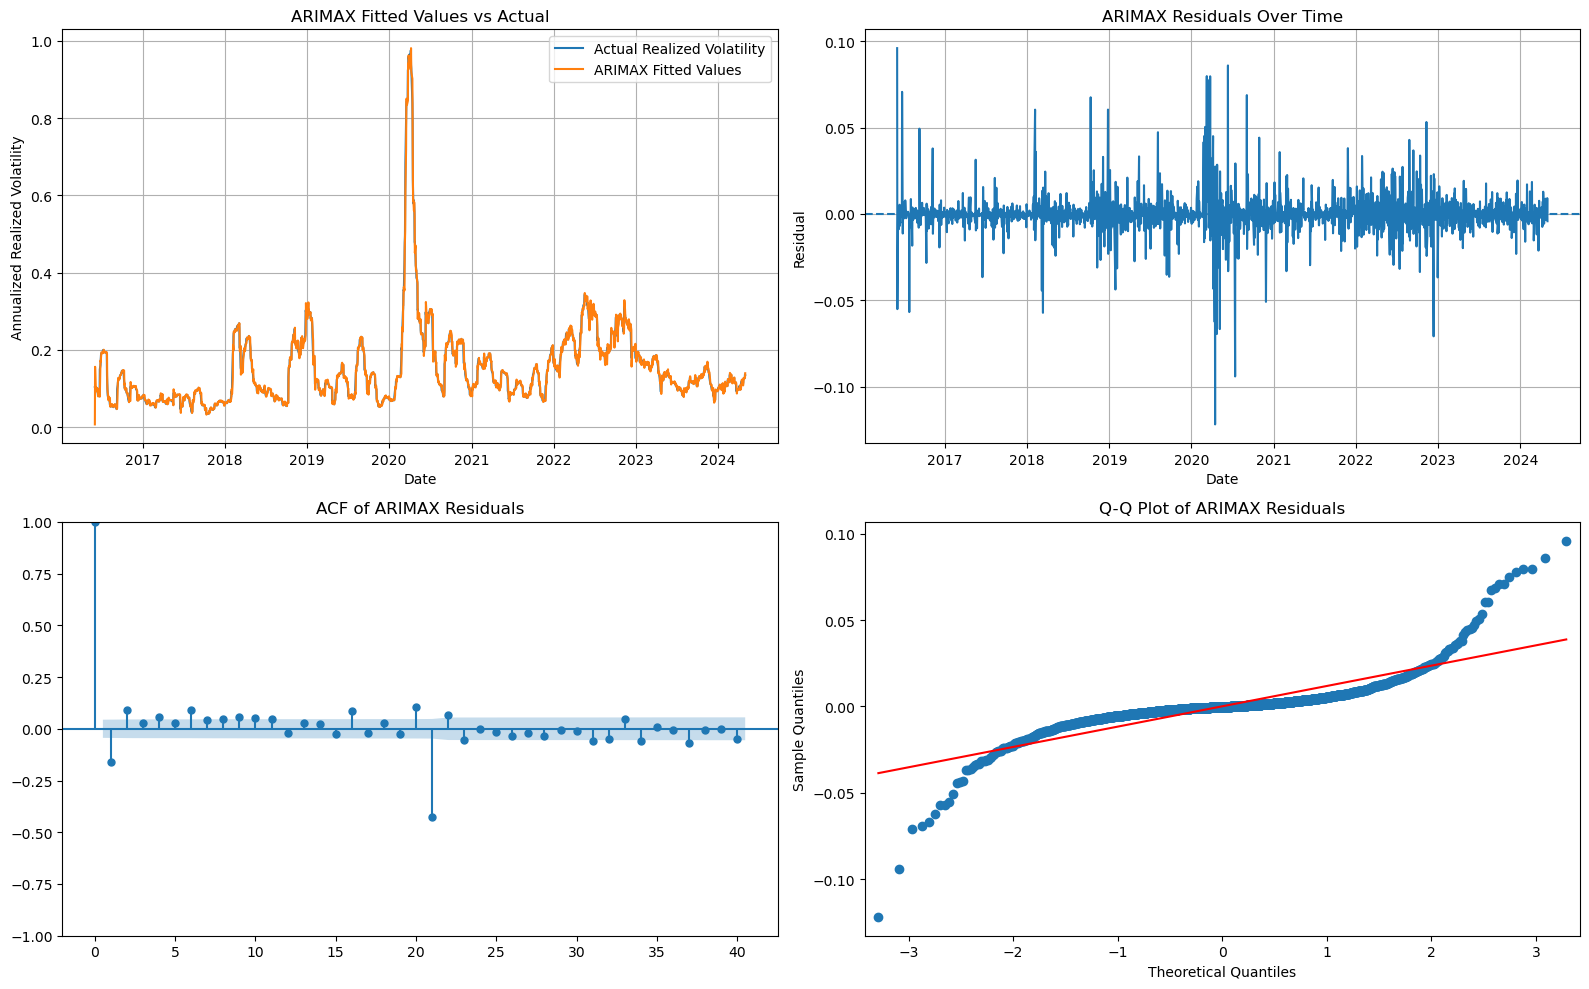

,lb_stat,lb_pvalue
10,114.716064,5.952463e-20
20,165.243662,7.265637e-25
30,554.886591,6.227860e-98


In [17]:
# ARIMAX Residual Diagnostics

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
import pandas as pd

# Extract fitted values and residuals
arimax_fitted = arimax_fit.fittedvalues
arimax_residuals = arimax_fit.resid

# Align diagnostics with ARIMAX training data
arimax_diag = pd.DataFrame({
    "date": arimax_train.loc[arimax_residuals.index, "date"],
    "actual": y_train_arimax.loc[arimax_residuals.index],
    "fitted": arimax_fitted,
    "residual": arimax_residuals
}).dropna()

# Create 2x2 diagnostic layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Actual vs fitted
axes[0, 0].plot(arimax_diag["date"], arimax_diag["actual"], label="Actual Realized Volatility")
axes[0, 0].plot(arimax_diag["date"], arimax_diag["fitted"], label="ARIMAX Fitted Values")
axes[0, 0].set_title("ARIMAX Fitted Values vs Actual")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Annualized Realized Volatility")
axes[0, 0].legend()
axes[0, 0].grid(True)

# Residuals over time
axes[0, 1].plot(arimax_diag["date"], arimax_diag["residual"])
axes[0, 1].axhline(0, linestyle="--")
axes[0, 1].set_title("ARIMAX Residuals Over Time")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Residual")
axes[0, 1].grid(True)

# ACF of residuals
plot_acf(arimax_diag["residual"], lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF of ARIMAX Residuals")

# Q-Q plot
qqplot(arimax_diag["residual"], line="s", ax=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of ARIMAX Residuals")

plt.tight_layout()
plt.show()

# Ljung-Box residual autocorrelation test
arimax_ljung_box = acorr_ljungbox(
    arimax_diag["residual"],
    lags=[10, 20, 30],
    return_df=True
)

display(arimax_ljung_box)

### ARIMAX Residual Diagnostics Interpretation

The ARIMAX residual diagnostics evaluate whether the model adequately captures the remaining time-series structure after adding lagged VIX and GVZ as external predictors. The fitted-values plot shows that ARIMAX tracks the broad movements in S&P 500 realized volatility during the training period, including major volatility episodes. This suggests that the model captures much of the persistence in realized volatility.

The residual time-series plot shows that residuals are generally centered around zero, but larger residual spikes remain during high-volatility periods, especially around the 2020 stress period and other market turbulence episodes. This indicates that ARIMAX improves the mean forecasting structure by adding external predictors, but it does not fully eliminate large unexplained volatility shocks.

The residual ACF plot shows that some residual autocorrelation remains, especially around the 20-to-21 lag region. This is important because the target variable is constructed using a 21-day rolling realized-volatility window, so nearby observations share many of the same underlying return observations. This rolling-window construction can create persistent dependence that is difficult for a simple ARIMAX model to remove completely.

The Q-Q plot shows clear departures from normality in both tails. This indicates heavy-tailed residual behavior, which is common in financial volatility data. The model is therefore useful as a forecasting benchmark, but the residual distribution suggests that extreme volatility events are not fully captured by a linear ARIMAX specification.

The Ljung-Box test evaluates whether the ARIMAX residuals still contain statistically significant autocorrelation. The p-values at lags 10, 20, and 30 are all far below the 5% significance level, so the null hypothesis of no residual autocorrelation is rejected. This means that the ARIMAX residuals still contain remaining serial dependence after fitting the model.

Overall, ARIMAX captures part of the realized-volatility structure and incorporates useful external volatility information, especially from lagged GVZ. However, the residual diagnostics show that ARIMAX does not fully remove serial dependence or heavy-tailed behavior. Therefore, ARIMAX should be treated as an improved linear benchmark rather than a final complete volatility model. Its value will be judged primarily by out-of-sample rolling forecast performance relative to ARIMA, GARCH/EGARCH, and Random Forest.

### ARIMAX Rolling One-Step-Ahead Forecast

The ARIMAX rolling one-step-ahead forecast evaluates how the model performs in an out-of-sample forecasting setting after adding lagged VIX and lagged GVZ as external predictors. This procedure uses the fitted ARIMAX model to forecast one test-period observation at a time, then updates the model history after the actual value becomes available.

This rolling setup is used because daily financial volatility forecasts are typically updated as new market data arrive. It preserves the chronological order of the data and avoids look-ahead leakage because each forecast only uses information that would have been available at the time of prediction. The exogenous predictors are lagged by one trading day, so the model uses prior-day VIX and GVZ information rather than same-day values.

The forecast output will be compared against actual S&P 500 21-day realized volatility over the test period. Forecast accuracy is evaluated using MAE and RMSE, and the plot includes a 95% prediction interval to show forecast uncertainty. This result will determine whether adding VIX and GVZ improves forecasting performance relative to the rolling ARIMA benchmark.

,model,order,exogenous_predictors,MAE,RMSE
0,ARIMAX Rolling One-Step,"(2, 0, 1)","vix_lag1, gvz_lag1",0.006259,0.013556


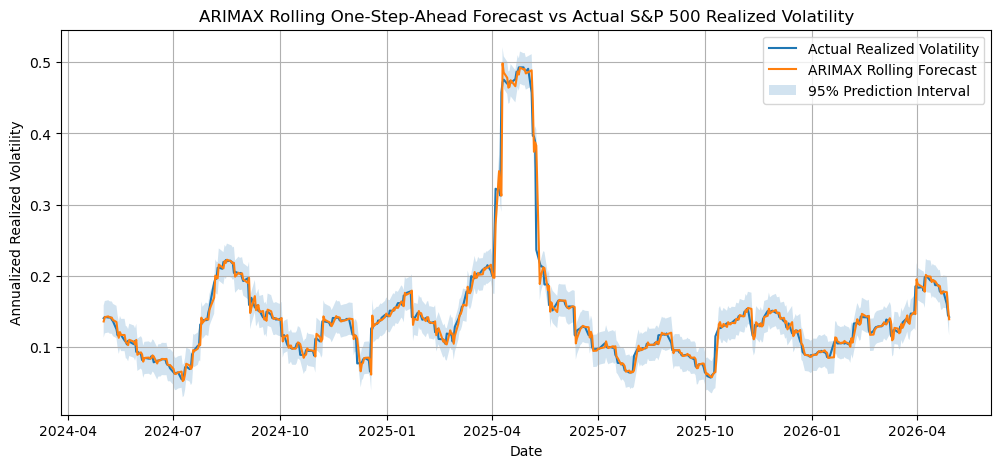

In [18]:
# ARIMAX Rolling One-Step-Ahead Forecast with Prediction Intervals

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rolling_arimax_results = arimax_fit

arimax_rolling_forecasts = []
arimax_rolling_lower = []
arimax_rolling_upper = []

for idx in y_test_arimax.index:
    
    # Use the lagged VIX and GVZ values available for this forecast step
    next_exog = X_test_arimax.loc[[idx]]
    
    # One-step-ahead forecast
    forecast_obj = rolling_arimax_results.get_forecast(
        steps=1,
        exog=next_exog
    )
    
    forecast_mean = forecast_obj.predicted_mean.iloc[0]
    forecast_ci = forecast_obj.conf_int(alpha=0.05).iloc[0]
    
    arimax_rolling_forecasts.append(forecast_mean)
    arimax_rolling_lower.append(forecast_ci.iloc[0])
    arimax_rolling_upper.append(forecast_ci.iloc[1])
    
    # Append the actual observed value and matching exogenous row
    new_y = pd.Series(
        [y_test_arimax.loc[idx]],
        index=[idx],
        name=y_train_arimax.name
    )
    
    new_X = X_test_arimax.loc[[idx]]
    
    rolling_arimax_results = rolling_arimax_results.append(
        endog=new_y,
        exog=new_X,
        refit=False
    )

# Convert forecasts to Series
arimax_rolling_forecast = pd.Series(
    arimax_rolling_forecasts,
    index=arimax_test.index,
    name="arimax_rolling_forecast"
)

arimax_rolling_lower = pd.Series(
    arimax_rolling_lower,
    index=arimax_test.index,
    name="arimax_rolling_lower"
)

arimax_rolling_upper = pd.Series(
    arimax_rolling_upper,
    index=arimax_test.index,
    name="arimax_rolling_upper"
)

# Evaluate ARIMAX forecast
arimax_rolling_mae = mean_absolute_error(y_test_arimax, arimax_rolling_forecast)
arimax_rolling_rmse = np.sqrt(mean_squared_error(y_test_arimax, arimax_rolling_forecast))

arimax_eval = pd.DataFrame({
    "model": ["ARIMAX Rolling One-Step"],
    "order": [arimax_order],
    "exogenous_predictors": [", ".join(exog_cols)],
    "MAE": [arimax_rolling_mae],
    "RMSE": [arimax_rolling_rmse]
})

display(arimax_eval)

# Plot actual vs ARIMAX rolling forecast
plt.figure(figsize=(12, 5))
plt.plot(arimax_test["date"], y_test_arimax, label="Actual Realized Volatility")
plt.plot(arimax_test["date"], arimax_rolling_forecast, label="ARIMAX Rolling Forecast")
plt.fill_between(
    arimax_test["date"],
    arimax_rolling_lower,
    arimax_rolling_upper,
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.title("ARIMAX Rolling One-Step-Ahead Forecast vs Actual S&P 500 Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Realized Volatility")
plt.legend()
plt.grid(True)
plt.show()

### ARIMAX Rolling Forecast Interpretation

The ARIMAX rolling one-step-ahead forecast evaluates whether adding lagged VIX and lagged GVZ improves realized-volatility forecasting beyond the univariate ARIMA benchmark. The model uses the same ARIMA(2, 0, 1) structure selected earlier, but adds external volatility indicators from the previous trading day.

The ARIMAX forecast tracks the realized-volatility path closely across the test period. It captures the broad rise and fall of volatility, including the major volatility spike in 2025. This reflects the benefit of using a rolling one-step-ahead setup, where the model history is updated after each observed test-period value becomes available.

The ARIMAX model produced an MAE of approximately **0.0063** and an RMSE of approximately **0.0136**. These values indicate that the average absolute forecast error was slightly above 0.6 percentage points of annualized volatility, while the larger RMSE reflects greater penalty for errors during sharper volatility movements.

Although the ARIMAX model includes lagged VIX and GVZ, its forecast errors are slightly higher than the rolling ARIMA benchmark. This suggests that, during this test period, the additional external volatility indicators did not improve forecast accuracy beyond the information already contained in recent realized volatility. This does not mean VIX or GVZ are irrelevant overall; rather, their incremental value was limited in this specific ARIMAX specification and forecast window.

Overall, ARIMAX remains a useful linear benchmark because it directly tests whether external volatility indicators improve realized-volatility forecasts. However, based on MAE and RMSE, the rolling ARIMA model performs slightly better than ARIMAX in this comparison.

## Comparison between ARIMA and ARIMAX Rolling Forecasts

,model,order,predictors,MAE,RMSE
0,ARIMA Rolling One-Step,"(2, 0, 1)",Past realized volatility only,0.006124,0.013154
1,ARIMAX Rolling One-Step,"(2, 0, 1)",Past realized volatility + lagged VIX + lagged...,0.006259,0.013556


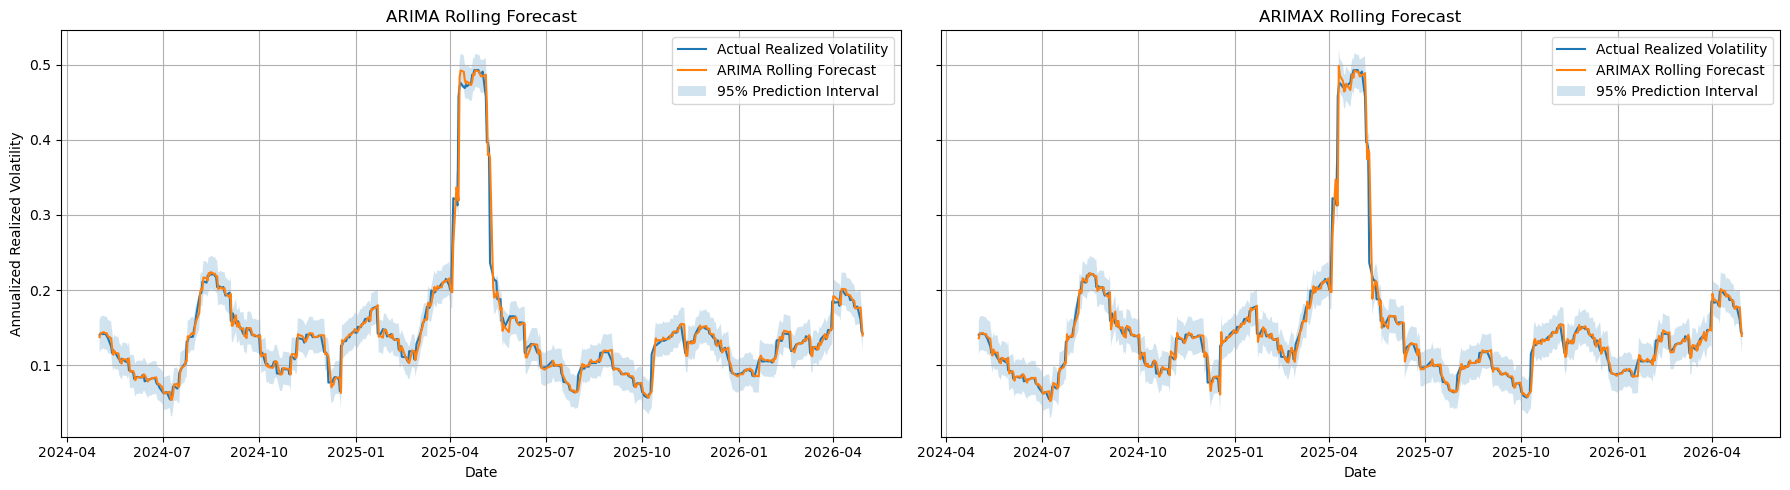

In [19]:
# ARIMA vs ARIMAX Rolling Forecast Comparison

import matplotlib.pyplot as plt
import pandas as pd

# Create comparison table
arima_arimax_comparison = pd.DataFrame({
    "model": ["ARIMA Rolling One-Step", "ARIMAX Rolling One-Step"],
    "order": [best_arima_order, arimax_order],
    "predictors": [
        "Past realized volatility only",
        "Past realized volatility + lagged VIX + lagged GVZ"
    ],
    "MAE": [arima_rolling_mae, arimax_rolling_mae],
    "RMSE": [arima_rolling_rmse, arimax_rolling_rmse]
})

display(arima_arimax_comparison)

# Side-by-side forecast plots
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

# ARIMA plot
axes[0].plot(test["date"], y_test, label="Actual Realized Volatility")
axes[0].plot(test["date"], arima_rolling_forecast, label="ARIMA Rolling Forecast")
axes[0].fill_between(
    test["date"],
    arima_rolling_lower,
    arima_rolling_upper,
    alpha=0.2,
    label="95% Prediction Interval"
)
axes[0].set_title("ARIMA Rolling Forecast")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Annualized Realized Volatility")
axes[0].legend()
axes[0].grid(True)

# ARIMAX plot
axes[1].plot(arimax_test["date"], y_test_arimax, label="Actual Realized Volatility")
axes[1].plot(arimax_test["date"], arimax_rolling_forecast, label="ARIMAX Rolling Forecast")
axes[1].fill_between(
    arimax_test["date"],
    arimax_rolling_lower,
    arimax_rolling_upper,
    alpha=0.2,
    label="95% Prediction Interval"
)
axes[1].set_title("ARIMAX Rolling Forecast")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### ARIMA vs ARIMAX Forecast Comparison

The ARIMA and ARIMAX models were compared using the same rolling one-step-ahead forecasting framework. This makes the comparison fair because both models are evaluated on out-of-sample test observations while updating the model history sequentially through time.

The ARIMA model uses only past S&P 500 realized volatility and past forecast errors. The ARIMAX model extends this structure by adding lagged VIX and lagged GVZ as external predictors. Therefore, the comparison tests whether implied equity-market volatility and gold-market volatility improve forecasts beyond the information already contained in recent realized volatility.

The ARIMA model produced an MAE of approximately **0.0061** and an RMSE of approximately **0.0132**. The ARIMAX model produced an MAE of approximately **0.0063** and an RMSE of approximately **0.0136**. Since lower MAE and RMSE indicate better forecast accuracy, ARIMA performed slightly better than ARIMAX over this test period.

This result suggests that recent realized volatility already contains most of the useful short-run forecasting information for this target. Although lagged GVZ was statistically significant in the ARIMAX model fit and lagged VIX was marginally suggestive, the added predictors did not improve out-of-sample forecast accuracy. This distinction is important: statistical significance inside the fitted model does not guarantee better forecasting performance.

Based on this comparison, ARIMA is the stronger linear benchmark for this test period. ARIMAX remains useful because it tests whether external volatility indicators add predictive value, but its slightly worse MAE and RMSE suggest that the added predictors did not improve practical forecast performance here.

## Model 3: GARCH Modeling of S&P 500 Return Volatility

The third model is GARCH, which is used to model time-varying volatility in the S&P 500 log return series. Unlike ARIMA and ARIMAX, which forecast the 21-day realized-volatility target directly, GARCH models the conditional variance of returns. This is appropriate because the earlier ARCH LM test and squared-return ACF showed evidence of volatility clustering.

The GARCH model is fit to S&P 500 log returns rather than the S&P 500 price level or the realized-volatility target. This follows the standard financial time-series approach: returns are closer to stationary than raw prices, while volatility is represented through the changing conditional variance of those returns.

A baseline GARCH(1,1) model is used first. The model includes one lag of squared return shocks and one lag of past conditional variance. After fitting the model, standardized residual diagnostics are used to check whether the model has removed most remaining autocorrelation and ARCH effects. The key diagnostic checks are the ACF of standardized residuals, the ACF of squared standardized residuals, Ljung-Box tests, and an ARCH LM test on the standardized residuals.

   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------- ----------------- 524.3/929.7 kB 1.5 MB/s eta 0:00:01
   --------------------------------- ------ 786.4/929.7 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 929.7/929.7 kB 1.4 MB/s  0:00:00
                        Constant Mean - GARCH Model Results                         
Dep. Variable:             sp500_log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2485.44
Distribution:      Standardized Student's t   AIC:                           4980.88
Method:                  Maximum Likelihood   BIC:                           5008.87
                                              No. Observations:                 1993
Date:                     

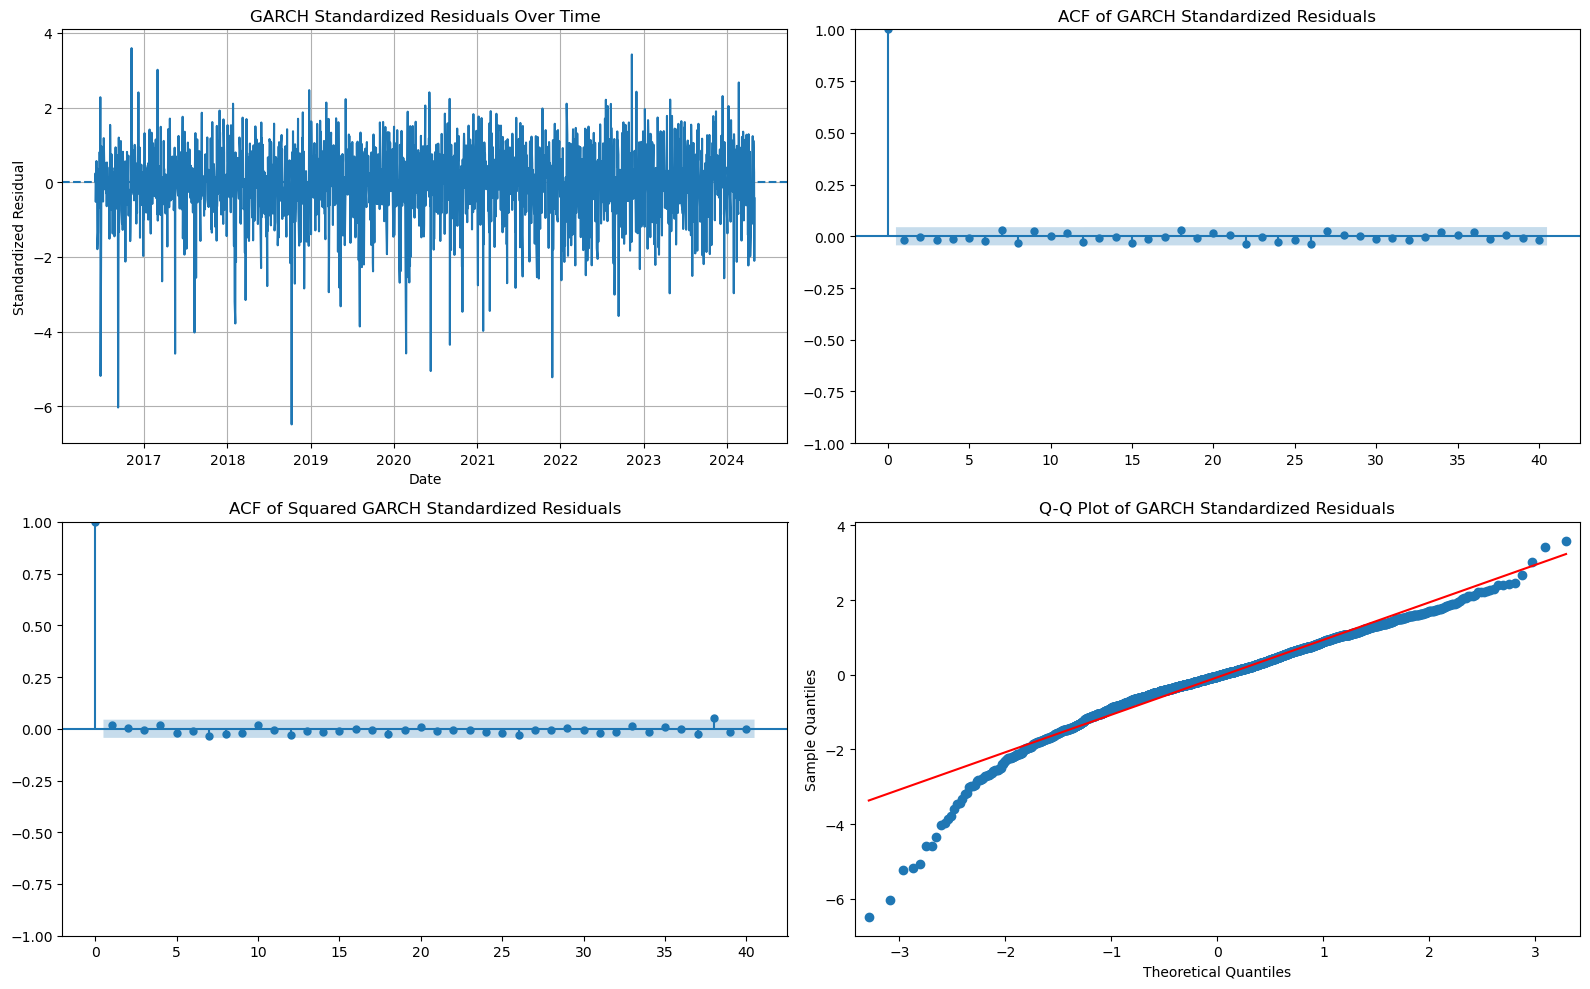

Ljung-Box Test: Standardized Residuals


,lb_stat,lb_pvalue
10,8.185319,0.610741
20,15.588734,0.741788
30,25.655464,0.692595


Ljung-Box Test: Squared Standardized Residuals


,lb_stat,lb_pvalue
10,7.306110,0.696265
20,11.794190,0.922978
30,15.506433,0.986548


ARCH LM Test on GARCH Standardized Residuals


,test,lags,lm_stat,lm_pvalue,f_stat,f_pvalue
0,ARCH LM Test on GARCH Std. Residuals,12,8.974328,0.705122,0.746334,0.706482


GARCH Volatility Persistence


,alpha_1,beta_1,alpha_plus_beta
0,0.170759,0.829241,1.0


In [21]:
# Model 3: GARCH(1,1) Fit and Residual Diagnostics

!pip install arch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# Use S&P 500 log returns from the same chronological train/test split
# Scale returns by 100 for numerical stability in GARCH estimation
garch_train_returns = train["sp500_log_return"].dropna() * 100

# Fit baseline GARCH(1,1)
# mean="Constant": allows a small mean return term
# vol="GARCH", p=1, q=1: standard GARCH(1,1)
# dist="t": Student-t errors allow heavier tails, common in financial returns
garch_model = arch_model(
    garch_train_returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

garch_fit = garch_model.fit(disp="off")

print(garch_fit.summary())


# GARCH residual diagnostics
# Standardized residuals should behave closer to white noise if the model fits well
garch_std_resid = pd.Series(
    garch_fit.std_resid,
    index=garch_train_returns.index,
    name="garch_standardized_residual"
).dropna()

# Align residuals with dates
garch_diag = pd.DataFrame({
    "date": train.loc[garch_std_resid.index, "date"],
    "standardized_residual": garch_std_resid,
    "squared_standardized_residual": garch_std_resid ** 2
}).dropna()

# 2x2 diagnostic layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Standardized residuals over time
axes[0, 0].plot(garch_diag["date"], garch_diag["standardized_residual"])
axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_title("GARCH Standardized Residuals Over Time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Standardized Residual")
axes[0, 0].grid(True)

# ACF of standardized residuals
plot_acf(garch_diag["standardized_residual"], lags=40, ax=axes[0, 1])
axes[0, 1].set_title("ACF of GARCH Standardized Residuals")

# ACF of squared standardized residuals
plot_acf(garch_diag["squared_standardized_residual"], lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF of Squared GARCH Standardized Residuals")

# Q-Q plot
qqplot(garch_diag["standardized_residual"], line="s", ax=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of GARCH Standardized Residuals")

plt.tight_layout()
plt.show()

# Ljung-Box tests on standardized residuals
# Tests remaining autocorrelation in mean equation residuals
garch_lb_resid = acorr_ljungbox(
    garch_diag["standardized_residual"],
    lags=[10, 20, 30],
    return_df=True
)

# Ljung-Box tests on squared standardized residuals
# Tests remaining volatility clustering not captured by GARCH
garch_lb_sq_resid = acorr_ljungbox(
    garch_diag["squared_standardized_residual"],
    lags=[10, 20, 30],
    return_df=True
)

# ARCH LM test on standardized residuals
# Tests whether remaining ARCH effects are still present
garch_arch_test = het_arch(garch_diag["standardized_residual"], nlags=12)

garch_arch_results = pd.DataFrame({
    "test": ["ARCH LM Test on GARCH Std. Residuals"],
    "lags": [12],
    "lm_stat": [garch_arch_test[0]],
    "lm_pvalue": [garch_arch_test[1]],
    "f_stat": [garch_arch_test[2]],
    "f_pvalue": [garch_arch_test[3]]
})

print("Ljung-Box Test: Standardized Residuals")
display(garch_lb_resid)

print("Ljung-Box Test: Squared Standardized Residuals")
display(garch_lb_sq_resid)

print("ARCH LM Test on GARCH Standardized Residuals")
display(garch_arch_results)

# Persistence check
# For GARCH(1,1), alpha + beta close to 1 means volatility is highly persistent.
params = garch_fit.params

alpha = params.get("alpha[1]", np.nan)
beta = params.get("beta[1]", np.nan)
persistence = alpha + beta

garch_persistence = pd.DataFrame({
    "alpha_1": [alpha],
    "beta_1": [beta],
    "alpha_plus_beta": [persistence]
})

print("GARCH Volatility Persistence")
display(garch_persistence)

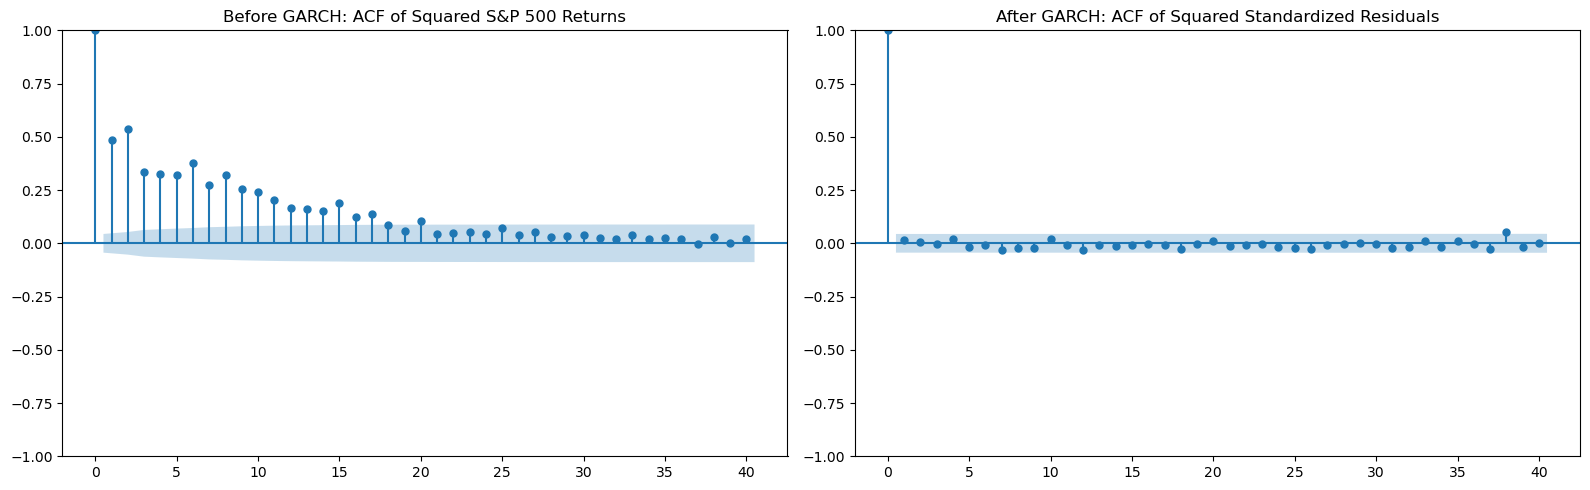

,stage,test,lags,lm_stat,lm_pvalue,f_stat,f_pvalue
0,Before GARCH,ARCH LM,12,791.516574,1.091029e-161,109.130330,8.354822e-208
1,After GARCH,ARCH LM,12,8.974328,7.051216e-01,0.746334,7.064819e-01


In [22]:
# Before vs After GARCH: Volatility Clustering Diagnostic

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch
import matplotlib.pyplot as plt
import pandas as pd

# Pre-GARCH: squared S&P 500 log returns from training set
# Returns were scaled by 100 for GARCH estimation
pre_garch_returns = train["sp500_log_return"].dropna() * 100
pre_garch_squared_returns = (pre_garch_returns - pre_garch_returns.mean()) ** 2

# Post-GARCH: squared standardized residuals
post_garch_squared_std_resid = garch_diag["squared_standardized_residual"].dropna()

# Side-by-side ACF comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(pre_garch_squared_returns, lags=40, ax=axes[0])
axes[0].set_title("Before GARCH: ACF of Squared S&P 500 Returns")

plot_acf(post_garch_squared_std_resid, lags=40, ax=axes[1])
axes[1].set_title("After GARCH: ACF of Squared Standardized Residuals")

plt.tight_layout()
plt.show()

# ARCH LM before and after GARCH
arch_before = het_arch(pre_garch_returns.dropna(), nlags=12)
arch_after = het_arch(garch_diag["standardized_residual"].dropna(), nlags=12)

arch_before_after = pd.DataFrame({
    "stage": ["Before GARCH", "After GARCH"],
    "test": ["ARCH LM", "ARCH LM"],
    "lags": [12, 12],
    "lm_stat": [arch_before[0], arch_after[0]],
    "lm_pvalue": [arch_before[1], arch_after[1]],
    "f_stat": [arch_before[2], arch_after[2]],
    "f_pvalue": [arch_before[3], arch_after[3]]
})

display(arch_before_after)

### GARCH Model Fit and Residual Diagnostics Interpretation

The GARCH(1,1) model was fit to S&P 500 log returns, scaled by 100 for numerical stability. This differs from ARIMA and ARIMAX because GARCH does not forecast the realized-volatility target directly. Instead, it models the conditional variance of the return process, which represents time-varying volatility.

The reason for fitting GARCH comes from the earlier diagnostics. The raw S&P 500 log returns showed weak linear autocorrelation, meaning return direction was not strongly predictable from its own past values. However, squared log returns showed much stronger dependence, meaning the magnitude of market movements was persistent. This is nonlinear dependence: returns may be close to uncorrelated, but squared returns can still be correlated. This pattern indicates volatility clustering and motivates GARCH modeling.

The before-and-after diagnostic confirms this visually and statistically. Before fitting GARCH, the ACF of squared S&P 500 returns showed strong positive autocorrelation across many lags, indicating that volatility clustering was present in the raw return process. The ARCH LM test before GARCH strongly rejected the null hypothesis of no ARCH effects, with an LM p-value of approximately **1.09 × 10⁻¹⁶¹** and an F-test p-value of approximately **8.35 × 10⁻²⁰⁸**. This provides formal evidence that past squared shocks helped explain current volatility.

After fitting GARCH(1,1), the ACF of squared standardized residuals shows little remaining autocorrelation, with most lag values close to zero and inside the confidence bands. The ARCH LM test after GARCH has an LM p-value of approximately **0.705** and an F-test p-value of approximately **0.706**, both above the 5% significance level. Therefore, the null hypothesis of no remaining ARCH effects is not rejected. This indicates that the GARCH model captured much of the conditional heteroskedasticity present in the original return series.

The estimated mean parameter, `mu`, represents the average daily log return after scaling returns by 100. The main focus, however, is the volatility equation. The `omega` parameter is the baseline variance constant. The `alpha[1]` coefficient measures how strongly current volatility responds to recent squared return shocks, while the `beta[1]` coefficient measures how strongly current volatility depends on past conditional volatility.

The estimated `omega`, `alpha[1]`, and `beta[1]` coefficients are statistically significant. This indicates that S&P 500 volatility responds to recent shocks and remains persistent over time. The estimated persistence value, `alpha[1] + beta[1]`, is approximately **1.0**. This means volatility shocks decay very slowly. High persistence is common in equity-market volatility, but a value near 1.0 should be noted because it suggests the model is close to the high-persistence boundary. As a practical interpretation, lower persistence values such as **0.60–0.80** would imply that volatility shocks decay relatively quickly, while values around **0.80–0.95** indicate high persistence. Values above **0.95** are often interpreted as very persistent volatility, meaning shocks fade slowly. A value near **1.0** suggests near-unit persistence, where volatility shocks may have very long-lasting effects and the model approaches the boundary associated with integrated GARCH behavior. This is not unusual in financial volatility applications, but it should be noted because it affects long-horizon variance interpretation (Engle, 2001; NYU Stern Volatility Lab, n.d.).

The standardized residual plot shows residuals fluctuating around zero, with some extreme observations remaining during turbulent periods. Standardized residuals are the residual shocks after dividing by the model-estimated conditional volatility. If the GARCH model is adequate, these standardized residuals should behave closer to white noise.

The ACF of standardized residuals checks whether ordinary linear autocorrelation remains after fitting the model. The Ljung-Box p-values for standardized residuals at lags 10, 20, and 30 are all above the 5% significance level, so the null hypothesis of no residual autocorrelation is not rejected. This suggests that the model does not leave strong linear serial dependence in the standardized residuals.

The ACF of squared standardized residuals is the more important GARCH diagnostic because it checks whether volatility clustering remains after modeling conditional variance. The Ljung-Box p-values for squared standardized residuals at lags 10, 20, and 30 are also above the 5% significance level, so the null hypothesis of no autocorrelation in squared standardized residuals is not rejected. This supports the conclusion that GARCH removed most remaining volatility dependence.

The Q-Q plot still shows heavy-tailed residual behavior, especially in the lower tail. This is common in financial return data and supports the decision to use Student-t errors rather than normal errors. Overall, the residual diagnostics suggest that the GARCH(1,1) model adequately captures much of the conditional volatility structure in S&P 500 returns and is appropriate to carry forward into the forecasting stage.

The GARCH model produced relatively large positive AIC and BIC values compared with the earlier ARIMA and ARIMAX models. These values should not be directly compared across ARIMA and GARCH because the models are estimated on different dependent variables and scales. ARIMA and ARIMAX were fit to the 21-day realized-volatility target, while GARCH was fit to scaled daily S&P 500 log returns. Therefore, GARCH AIC and BIC are useful mainly for comparison against other GARCH-family models, such as EGARCH, rather than against ARIMA or ARIMAX.

Overall, the residual diagnostics suggest that the GARCH(1,1) model adequately captures much of the conditional volatility structure in S&P 500 returns and is appropriate to carry forward into the forecasting stage.

### GARCH Rolling Volatility Forecast

The next step is to evaluate whether the fitted GARCH(1,1) model can forecast S&P 500 realized volatility out of sample. Unlike ARIMA and ARIMAX, which forecast the 21-day realized-volatility target directly, GARCH models the conditional variance of daily S&P 500 log returns.

The GARCH forecast produces a one-step-ahead estimate of daily conditional volatility. To compare this forecast with the 21-day annualized realized-volatility target, the predicted daily conditional volatility is converted back from scaled return units and annualized using the standard approximation of 252 trading days per year.

A rolling one-step-ahead framework is used. At each test-period date, the model forecasts the next conditional volatility using the fitted GARCH parameters and the most recent observed return shock. The model parameters remain fixed from the training fit, while the volatility recursion updates through the test period using newly observed returns. Forecast accuracy is evaluated using MAE and RMSE against the observed S&P 500 21-day realized volatility.

,model,order,distribution,MAE,RMSE
0,GARCH Rolling One-Step,"GARCH(1,1)",Student-t,0.024852,0.041759


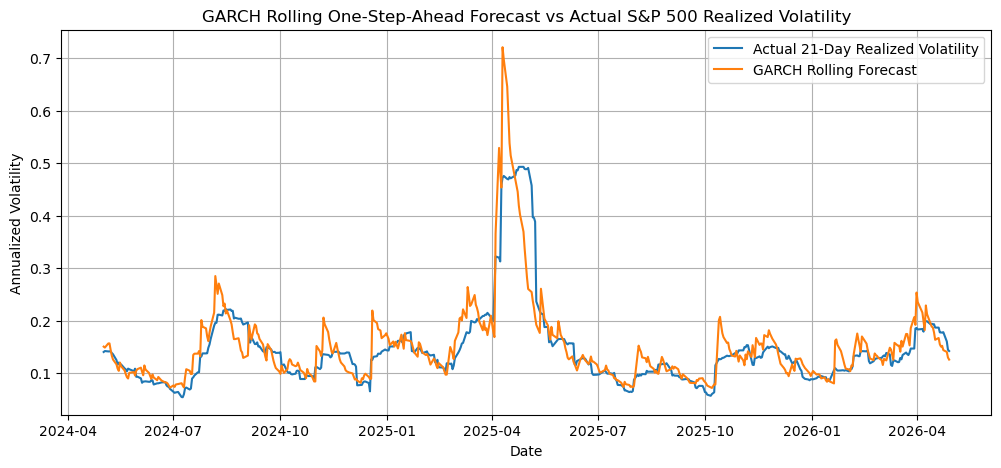

In [26]:
# GARCH Rolling One-Step-Ahead Volatility Forecast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Target for comparison
target_col = "sp500_realized_vol_21d"
return_col = "sp500_log_return"

# Make sure test data has both returns and realized volatility
garch_test = test[["date", return_col, target_col]].dropna().copy()

# Extract fitted GARCH(1,1) parameters
garch_params = garch_fit.params

mu = garch_params["mu"]
omega = garch_params["omega"]
alpha = garch_params["alpha[1]"]
beta = garch_params["beta[1]"]

# Last training values used to start the rolling recursion
# Returns were scaled by 100 in the GARCH model
train_returns_scaled = train[return_col].dropna() * 100

last_return_scaled = train_returns_scaled.iloc[-1]
last_resid = last_return_scaled - mu

# Last fitted conditional variance from the training model
# garch_fit.conditional_volatility is in scaled return units
last_cond_vol = garch_fit.conditional_volatility.dropna().iloc[-1]
last_cond_var = last_cond_vol ** 2

# Store forecasts
garch_vol_forecasts = []

# Rolling one-step-ahead GARCH variance recursion
for idx, row in garch_test.iterrows():
    
    # Forecast next conditional variance using GARCH(1,1)
    next_cond_var = omega + alpha * (last_resid ** 2) + beta * last_cond_var
    
    # Convert variance to daily volatility in scaled-return units
    next_cond_vol_scaled = np.sqrt(next_cond_var)
    
    # Convert from percent units back to decimal daily volatility
    next_cond_vol_daily = next_cond_vol_scaled / 100
    
    # Annualize daily volatility using sqrt(252)
    next_cond_vol_annualized = next_cond_vol_daily * np.sqrt(252)
    
    # Save forecast
    garch_vol_forecasts.append(next_cond_vol_annualized)
    
    # Update recursion using actual observed test return
    actual_return_scaled = row[return_col] * 100
    last_resid = actual_return_scaled - mu
    last_cond_var = next_cond_var

# Convert forecast list to Series aligned with test dates
garch_rolling_forecast = pd.Series(
    garch_vol_forecasts,
    index=garch_test.index,
    name="garch_rolling_forecast"
)

# Actual realized volatility
garch_actual = garch_test[target_col]

# Forecast accuracy
garch_rolling_mae = mean_absolute_error(garch_actual, garch_rolling_forecast)
garch_rolling_rmse = np.sqrt(mean_squared_error(garch_actual, garch_rolling_forecast))

garch_eval = pd.DataFrame({
    "model": ["GARCH Rolling One-Step"],
    "order": ["GARCH(1,1)"],
    "distribution": ["Student-t"],
    "MAE": [garch_rolling_mae],
    "RMSE": [garch_rolling_rmse]
})

display(garch_eval)

# Plot actual vs GARCH forecast
plt.figure(figsize=(12, 5))
plt.plot(garch_test["date"], garch_actual, label="Actual 21-Day Realized Volatility")
plt.plot(garch_test["date"], garch_rolling_forecast, label="GARCH Rolling Forecast")

plt.title("GARCH Rolling One-Step-Ahead Forecast vs Actual S&P 500 Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.show()

### GARCH Rolling Forecast Interpretation

The GARCH rolling one-step-ahead forecast evaluates whether conditional volatility estimated from S&P 500 log returns can forecast the 21-day annualized realized-volatility target. The GARCH forecast is more reactive than the ARIMA and ARIMAX forecasts because it updates conditional volatility based on recent return shocks rather than directly forecasting the smoothed realized-volatility series.

The GARCH model captures several broad volatility movements, including the large volatility spike in the test period. However, the forecast is more volatile than the realized-volatility target and tends to overshoot during sharp market movements. This is expected because the target variable is a 21-day rolling realized-volatility measure, while GARCH produces a daily conditional-volatility estimate from return shocks.

The GARCH model produced an MAE of approximately **0.0249** and an RMSE of approximately **0.0418**. These errors are larger than the ARIMA and ARIMAX rolling forecast errors, suggesting that GARCH does not outperform the direct realized-volatility forecasting models in this test period. The result does not invalidate GARCH; instead, it shows that modeling daily conditional return volatility is not necessarily the same as directly forecasting a smoothed 21-day realized-volatility target.

The GARCH forecast is more reactive than the ARIMA and ARIMAX forecasts because it is generated from daily return shocks rather than from the smoothed 21-day realized-volatility series. This explains why the GARCH forecast overshoots during sharp volatility spikes even though the residual diagnostics showed that the model captured volatility clustering well.

Overall, GARCH is useful for modeling volatility clustering in S&P 500 returns, and the residual diagnostics showed that it captured much of the conditional heteroskedasticity in the return process. However, based on this rolling forecast, it is not currently the strongest model for forecasting the 21-day realized-volatility target.

## Model 4: EGARCH Modeling of S&P 500 Return Volatility

The fourth model is EGARCH, which extends the GARCH framework by allowing volatility to respond asymmetrically to positive and negative return shocks. This is useful for financial return data because negative market shocks often have a stronger effect on future volatility than positive shocks of similar size.

Like GARCH, EGARCH is fit to the S&P 500 log return series rather than directly to the 21-day realized-volatility target. The model estimates time-varying conditional volatility from returns. EGARCH is included as a volatility-modeling extension to test whether allowing asymmetric shock effects improves the modeling of S&P 500 volatility.

A baseline EGARCH(1,1) model with Student-t errors is used. Student-t errors are retained because the GARCH residual diagnostics showed heavy-tailed behavior, which is common in financial returns. After fitting the model, the coefficient estimates and residual diagnostics are evaluated before moving to out-of-sample volatility forecasting.

In [23]:
# Model 4: EGARCH(1,1) Fit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arch import arch_model

# Use S&P 500 log returns from the same training set
# Scale returns by 100 for numerical stability
egarch_train_returns = train["sp500_log_return"].dropna() * 100

# Fit baseline EGARCH(1,1)
# mean="Constant": includes a constant mean return
# vol="EGARCH": exponential GARCH volatility model
# p=1: one symmetric shock term
# o=1: one asymmetric/leverage term
# q=1: one lagged log-volatility term
# dist="t": Student-t errors for heavy-tailed financial returns
egarch_model = arch_model(
    egarch_train_returns,
    mean="Constant",
    vol="EGARCH",
    p=1,
    o=1,
    q=1,
    dist="t"
)

egarch_fit = egarch_model.fit(disp="off")

print(egarch_fit.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:             sp500_log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -2455.03
Distribution:      Standardized Student's t   AIC:                           4922.06
Method:                  Maximum Likelihood   BIC:                           4955.64
                                              No. Observations:                 1993
Date:                      Sat, May 02 2026   Df Residuals:                     1992
Time:                              15:22:50   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

### EGARCH Residual Diagnostics

After fitting the EGARCH(1,1) model, residual diagnostics are used to evaluate whether the model adequately captures the remaining volatility structure in S&P 500 returns. These diagnostics focus on standardized residuals because EGARCH estimates time-varying conditional volatility and then scales residual shocks by that estimated volatility.

The diagnostic checks include the standardized residual plot, the ACF of standardized residuals, the ACF of squared standardized residuals, the Q-Q plot, Ljung-Box tests, and an ARCH LM test. The key question is whether the EGARCH model removes most remaining autocorrelation and volatility clustering from the standardized residual process.

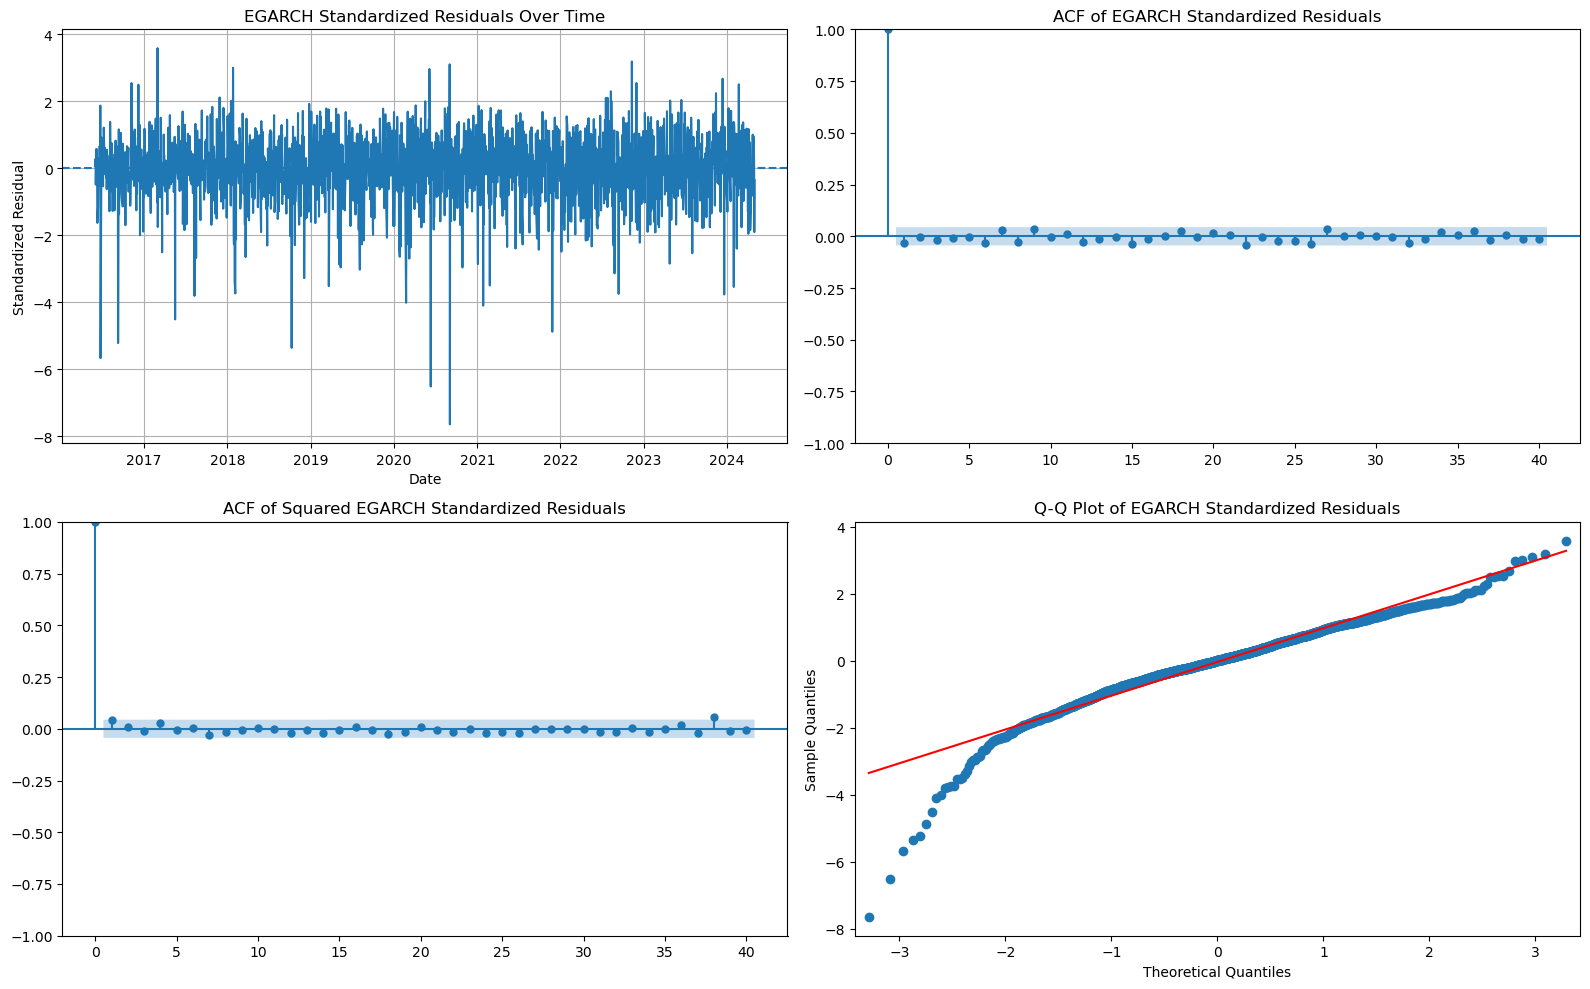

Ljung-Box Test: EGARCH Standardized Residuals


,lb_stat,lb_pvalue
10,11.381911,0.328548
20,18.465817,0.556752
30,29.826186,0.474581


Ljung-Box Test: Squared EGARCH Standardized Residuals


,lb_stat,lb_pvalue
10,7.990970,0.629719
20,12.102836,0.912491
30,14.852513,0.990547


ARCH LM Test on EGARCH Standardized Residuals


,test,lags,lm_stat,lm_pvalue,f_stat,f_pvalue
0,ARCH LM Test on EGARCH Std. Residuals,12,8.765903,0.722785,0.728924,0.724135


In [24]:
# EGARCH Residual Diagnostics

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract standardized residuals
egarch_std_resid = pd.Series(
    egarch_fit.std_resid,
    index=egarch_train_returns.index,
    name="egarch_standardized_residual"
).dropna()

# Align residuals with dates
egarch_diag = pd.DataFrame({
    "date": train.loc[egarch_std_resid.index, "date"],
    "standardized_residual": egarch_std_resid,
    "squared_standardized_residual": egarch_std_resid ** 2
}).dropna()

# 2x2 diagnostic layout
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Standardized residuals over time
axes[0, 0].plot(egarch_diag["date"], egarch_diag["standardized_residual"])
axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_title("EGARCH Standardized Residuals Over Time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Standardized Residual")
axes[0, 0].grid(True)

# ACF of standardized residuals
plot_acf(egarch_diag["standardized_residual"], lags=40, ax=axes[0, 1])
axes[0, 1].set_title("ACF of EGARCH Standardized Residuals")

# ACF of squared standardized residuals
plot_acf(egarch_diag["squared_standardized_residual"], lags=40, ax=axes[1, 0])
axes[1, 0].set_title("ACF of Squared EGARCH Standardized Residuals")

# Q-Q plot
qqplot(egarch_diag["standardized_residual"], line="s", ax=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot of EGARCH Standardized Residuals")

plt.tight_layout()
plt.show()

# Ljung-Box test on standardized residuals
egarch_lb_resid = acorr_ljungbox(
    egarch_diag["standardized_residual"],
    lags=[10, 20, 30],
    return_df=True
)

# Ljung-Box test on squared standardized residuals
egarch_lb_sq_resid = acorr_ljungbox(
    egarch_diag["squared_standardized_residual"],
    lags=[10, 20, 30],
    return_df=True
)

# ARCH LM test on standardized residuals
egarch_arch_test = het_arch(
    egarch_diag["standardized_residual"],
    nlags=12
)

egarch_arch_results = pd.DataFrame({
    "test": ["ARCH LM Test on EGARCH Std. Residuals"],
    "lags": [12],
    "lm_stat": [egarch_arch_test[0]],
    "lm_pvalue": [egarch_arch_test[1]],
    "f_stat": [egarch_arch_test[2]],
    "f_pvalue": [egarch_arch_test[3]]
})

print("Ljung-Box Test: EGARCH Standardized Residuals")
display(egarch_lb_resid)

print("Ljung-Box Test: Squared EGARCH Standardized Residuals")
display(egarch_lb_sq_resid)

print("ARCH LM Test on EGARCH Standardized Residuals")
display(egarch_arch_results)

### EGARCH Model Fit and Residual Diagnostics Interpretation

The EGARCH(1,1) model was fit to the same scaled S&P 500 log return series used in the GARCH model. EGARCH extends the standard GARCH framework by allowing volatility to respond asymmetrically to positive and negative return shocks. This is useful for equity-market returns because negative market shocks often have stronger effects on future volatility than positive shocks of similar size.

The EGARCH coefficient estimates show that the model captures important volatility dynamics. The `alpha[1]` coefficient is positive and statistically significant, indicating that the magnitude of return shocks affects volatility. The `gamma[1]` coefficient is negative and statistically significant, which provides evidence of asymmetric volatility behavior. In this context, the negative sign suggests that negative S&P 500 return shocks increase future volatility more strongly than positive shocks of similar size. This is the main reason for including EGARCH after the baseline GARCH model.

The `beta[1]` coefficient is approximately **0.974** and statistically significant, indicating high volatility persistence. This means that once volatility increases, it tends to remain elevated rather than immediately returning to normal. The Student-t degrees-of-freedom parameter, `nu`, is also statistically significant, supporting the use of Student-t errors for heavy-tailed financial return behavior.

The EGARCH AIC is approximately **4922.06**, which is lower than the GARCH AIC of approximately **4980.88**. Because both models are fit to the same scaled S&P 500 log return series, their AIC and BIC values can be compared directly. The lower EGARCH AIC suggests that EGARCH provides a better in-sample fit than the baseline GARCH model. This does not automatically prove that EGARCH will forecast realized volatility better out of sample, but it does support EGARCH as a useful volatility-modeling extension.

The EGARCH standardized residual plot shows residuals fluctuating around zero, with some large shocks remaining during turbulent market periods. The ACF of standardized residuals shows little remaining linear autocorrelation, and the Ljung-Box p-values at lags 10, 20, and 30 are all above the 5% significance level. Therefore, the null hypothesis of no residual autocorrelation is not rejected.

The ACF of squared standardized residuals also shows little remaining volatility clustering. The Ljung-Box p-values for squared standardized residuals are above the 5% significance level, so the null hypothesis of no autocorrelation in squared standardized residuals is not rejected. The ARCH LM test on EGARCH standardized residuals also has p-values above 0.05, with an LM p-value of approximately **0.728** and an F-test p-value of approximately **0.724**. This indicates that there is no strong evidence of remaining ARCH effects after fitting EGARCH.

The Q-Q plot still shows heavy-tailed residual behavior, especially in the lower tail. This is consistent with financial return data and does not invalidate the model, especially because Student-t errors were used. Overall, EGARCH appears to capture the conditional volatility structure well, removes most remaining volatility clustering from the standardized residuals, and improves in-sample fit relative to GARCH. The next step is to evaluate whether this improvement translates into better out-of-sample volatility forecasts.

### EGARCH Rolling Volatility Forecast

The next step is to evaluate whether the fitted EGARCH(1,1) model can forecast S&P 500 realized volatility out of sample. Like GARCH, EGARCH models the conditional volatility of daily S&P 500 log returns rather than directly forecasting the 21-day realized-volatility target.

EGARCH differs from GARCH by allowing volatility to respond asymmetrically to positive and negative return shocks. This is useful in equity markets because negative shocks often increase future volatility more strongly than positive shocks of similar size.

The EGARCH forecast produces a one-step-ahead estimate of daily conditional volatility. To compare it with the 21-day annualized realized-volatility target, the forecast is converted back from scaled return units and annualized using the standard approximation of 252 trading days per year. Forecast accuracy is evaluated using MAE and RMSE.

,model,order,distribution,MAE,RMSE
0,EGARCH Rolling One-Step,"EGARCH(1,1)",Student-t,0.032261,0.051294


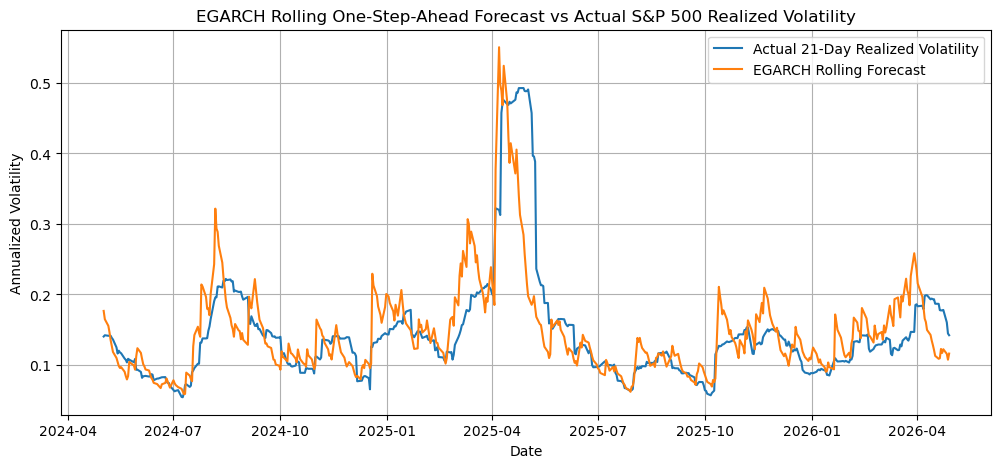

In [27]:
# EGARCH Rolling One-Step-Ahead Volatility Forecast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Target for comparison
target_col = "sp500_realized_vol_21d"
return_col = "sp500_log_return"

# Make sure test data has both returns and realized volatility
egarch_test = test[["date", return_col, target_col]].dropna().copy()

# Extract fitted EGARCH(1,1) parameters
egarch_params = egarch_fit.params

mu = egarch_params["mu"]
omega = egarch_params["omega"]
alpha = egarch_params["alpha[1]"]
gamma = egarch_params["gamma[1]"]
beta = egarch_params["beta[1]"]

# Last training values used to start rolling recursion
# Returns were scaled by 100 in the EGARCH model
train_returns_scaled = train[return_col].dropna() * 100

last_return_scaled = train_returns_scaled.iloc[-1]
last_resid = last_return_scaled - mu

# Last fitted conditional volatility from the training model
# EGARCH conditional volatility is in scaled return units
last_cond_vol = egarch_fit.conditional_volatility.dropna().iloc[-1]

# EGARCH models log variance
last_log_var = np.log(last_cond_vol ** 2)

# Store forecasts
egarch_vol_forecasts = []

# Rolling one-step-ahead EGARCH variance recursion
for idx, row in egarch_test.iterrows():
    
    # Standardized residual from previous step
    last_std_resid = last_resid / np.sqrt(np.exp(last_log_var))
    
    # EGARCH(1,1) log-variance recursion
    # log(sigma_t^2) = omega 
    #                  + alpha * (|z_{t-1}| - E|z|)
    #                  + gamma * z_{t-1}
    #                  + beta * log(sigma_{t-1}^2)
    #
    # For normal errors, E|z| ≈ sqrt(2/pi).
    # This is a practical approximation for the EGARCH recursion.
    expected_abs_z = np.sqrt(2 / np.pi)
    
    next_log_var = (
        omega
        + alpha * (abs(last_std_resid) - expected_abs_z)
        + gamma * last_std_resid
        + beta * last_log_var
    )
    
    # Convert log variance to conditional volatility in scaled-return units
    next_cond_vol_scaled = np.sqrt(np.exp(next_log_var))
    
    # Convert from percent units back to decimal daily volatility
    next_cond_vol_daily = next_cond_vol_scaled / 100
    
    # Annualize daily volatility using sqrt(252)
    next_cond_vol_annualized = next_cond_vol_daily * np.sqrt(252)
    
    # Save forecast
    egarch_vol_forecasts.append(next_cond_vol_annualized)
    
    # Update recursion using actual observed test return
    actual_return_scaled = row[return_col] * 100
    last_resid = actual_return_scaled - mu
    last_log_var = next_log_var

# Convert forecast list to Series aligned with test dates
egarch_rolling_forecast = pd.Series(
    egarch_vol_forecasts,
    index=egarch_test.index,
    name="egarch_rolling_forecast"
)

# Actual realized volatility
egarch_actual = egarch_test[target_col]

# Forecast accuracy
egarch_rolling_mae = mean_absolute_error(egarch_actual, egarch_rolling_forecast)
egarch_rolling_rmse = np.sqrt(mean_squared_error(egarch_actual, egarch_rolling_forecast))

egarch_eval = pd.DataFrame({
    "model": ["EGARCH Rolling One-Step"],
    "order": ["EGARCH(1,1)"],
    "distribution": ["Student-t"],
    "MAE": [egarch_rolling_mae],
    "RMSE": [egarch_rolling_rmse]
})

display(egarch_eval)

# Plot actual vs EGARCH forecast
plt.figure(figsize=(12, 5))
plt.plot(egarch_test["date"], egarch_actual, label="Actual 21-Day Realized Volatility")
plt.plot(egarch_test["date"], egarch_rolling_forecast, label="EGARCH Rolling Forecast")

plt.title("EGARCH Rolling One-Step-Ahead Forecast vs Actual S&P 500 Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.show()

### EGARCH Rolling Forecast Interpretation

The EGARCH rolling one-step-ahead forecast evaluates whether asymmetric conditional volatility estimated from S&P 500 log returns can forecast the 21-day annualized realized-volatility target. The model produced an MAE of approximately **0.0323** and an RMSE of approximately **0.0513** over the test period.

The forecast captures the general timing of several volatility movements, including the major volatility spike in 2025. However, the EGARCH forecast is more reactive than the observed 21-day realized-volatility series and overshoots during several periods. This occurs because EGARCH estimates daily conditional volatility from return shocks, while the target variable is a smoother 21-day rolling realized-volatility measure.

The EGARCH model includes an asymmetric volatility response, meaning negative return shocks can affect future volatility differently than positive shocks. This makes EGARCH useful for modeling equity-market volatility behavior, but the rolling forecast still shows that the model can overreact to sharp return movements when compared with the smoother realized-volatility target.

Overall, EGARCH provides a meaningful volatility-process forecast, but its accuracy should be judged against GARCH and the direct realized-volatility models using MAE and RMSE. The next step is to compare GARCH and EGARCH directly to determine whether the asymmetric volatility structure improved out-of-sample forecast performance.

### GARCH vs EGARCH Rolling Forecast Comparison

The GARCH and EGARCH models are compared using the same rolling one-step-ahead forecasting framework. Both models are fit to S&P 500 log returns and produce annualized conditional-volatility forecasts, which are then compared against the observed 21-day annualized realized-volatility target.

GARCH models volatility as a function of past squared return shocks and past conditional volatility. EGARCH extends this framework by allowing asymmetric volatility responses, meaning negative and positive return shocks can affect future volatility differently. This comparison evaluates whether the added asymmetric structure in EGARCH improves out-of-sample realized-volatility forecasts relative to the baseline GARCH model.

Forecast accuracy is evaluated using MAE and RMSE. Lower values indicate better predictive accuracy.

,model,order,distribution,MAE,RMSE
0,GARCH Rolling One-Step,"GARCH(1,1)",Student-t,0.024852,0.041759
1,EGARCH Rolling One-Step,"EGARCH(1,1)",Student-t,0.032261,0.051294


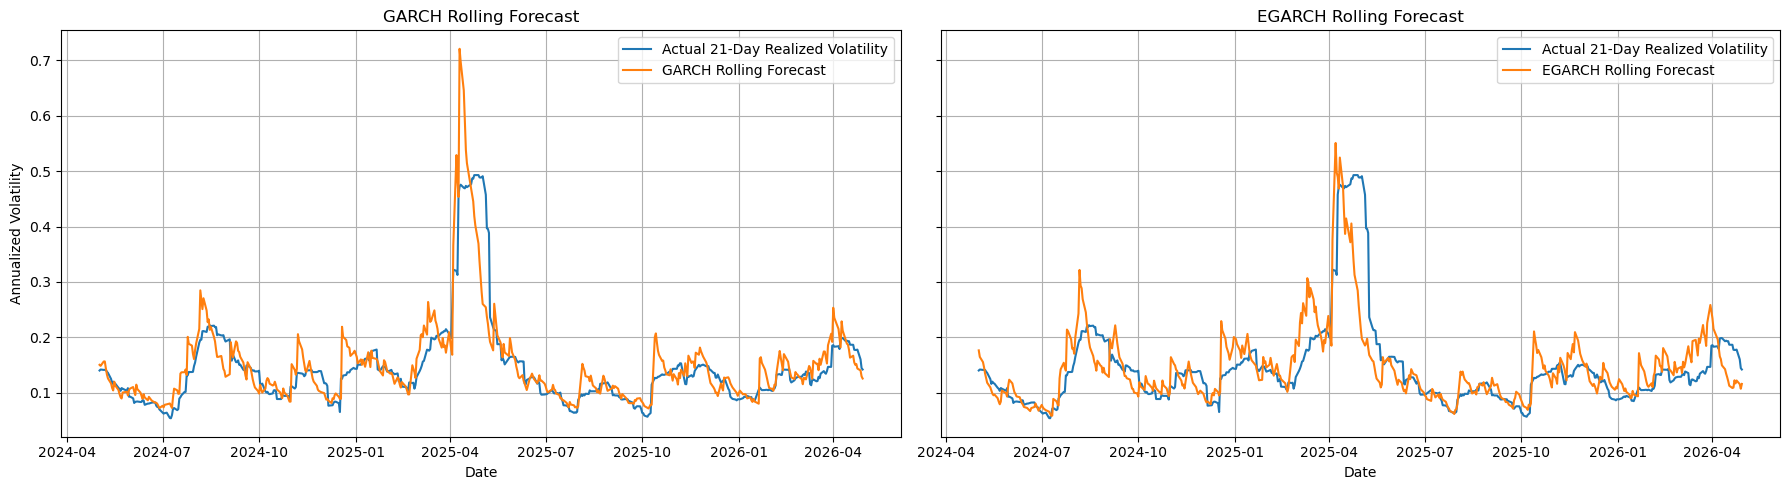

In [28]:
# GARCH vs EGARCH Rolling Forecast Comparison

import pandas as pd
import matplotlib.pyplot as plt

# Create comparison table
garch_egarch_comparison = pd.DataFrame({
    "model": ["GARCH Rolling One-Step", "EGARCH Rolling One-Step"],
    "order": ["GARCH(1,1)", "EGARCH(1,1)"],
    "distribution": ["Student-t", "Student-t"],
    "MAE": [garch_rolling_mae, egarch_rolling_mae],
    "RMSE": [garch_rolling_rmse, egarch_rolling_rmse]
})

display(garch_egarch_comparison)

# Side-by-side forecast plots
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

# GARCH plot
axes[0].plot(
    garch_test["date"],
    garch_actual,
    label="Actual 21-Day Realized Volatility"
)
axes[0].plot(
    garch_test["date"],
    garch_rolling_forecast,
    label="GARCH Rolling Forecast"
)
axes[0].set_title("GARCH Rolling Forecast")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Annualized Volatility")
axes[0].legend()
axes[0].grid(True)

# EGARCH plot
axes[1].plot(
    egarch_test["date"],
    egarch_actual,
    label="Actual 21-Day Realized Volatility"
)
axes[1].plot(
    egarch_test["date"],
    egarch_rolling_forecast,
    label="EGARCH Rolling Forecast"
)
axes[1].set_title("EGARCH Rolling Forecast")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### GARCH vs EGARCH Forecast Comparison Interpretation

The GARCH and EGARCH rolling forecasts both estimate conditional volatility from S&P 500 log returns and compare those volatility forecasts against the 21-day annualized realized-volatility target. The two models are similar in purpose, but EGARCH adds an asymmetric shock term that allows negative and positive returns to affect volatility differently.

The GARCH model produced an MAE of approximately **0.0249** and an RMSE of approximately **0.0418**. The EGARCH model produced an MAE of approximately **0.0323** and an RMSE of approximately **0.0513**. Since lower MAE and RMSE indicate better forecast accuracy, the baseline GARCH model outperformed EGARCH over this test period.

Visually, both models capture the general timing of volatility increases, including the large volatility spike in 2025. However, EGARCH appears more reactive and produces larger overshoots during some market-stress periods. This suggests that while the asymmetric EGARCH structure improved in-sample fit relative to GARCH, it did not improve out-of-sample realized-volatility forecast accuracy in this test window.

This distinction is important. EGARCH had a lower AIC than GARCH when fit to the return series, suggesting better in-sample fit to the conditional-volatility process. However, the rolling forecast comparison shows that better in-sample fit did not translate into better realized-volatility prediction. Based on MAE and RMSE, GARCH is the stronger volatility-process forecasting model for this target.

Because these are baseline GARCH-family specifications, the result should be interpreted as a comparison of standard GARCH(1,1) and EGARCH(1,1) models rather than proof that all possible EGARCH specifications would underperform. Alternative EGARCH orders or additional volatility-model variants could be tested in future work, but the baseline comparison shows that EGARCH's better in-sample fit did not translate into better out-of-sample realized-volatility forecasting for this test window.

Overall, both GARCH-family models are useful for modeling volatility clustering in S&P 500 returns, but neither has outperformed the direct ARIMA realized-volatility benchmark so far. The next model, Random Forest, will test whether nonlinear lagged predictors can improve forecast accuracy beyond the classical time-series and volatility-process models.

## Model 5: Random Forest Forecasting of S&P 500 Realized Volatility

The fifth model is Random Forest, a machine-learning benchmark used to test whether nonlinear relationships among lagged volatility indicators improve forecasts of S&P 500 21-day realized volatility. Unlike ARIMA and ARIMAX, Random Forest does not estimate a parametric time-series equation. Unlike GARCH and EGARCH, it does not explicitly model conditional variance. Instead, it learns nonlinear prediction rules from lagged input features.

Because Random Forest does not automatically understand time ordering, the time-series structure must be created manually through lagged predictors. The target variable remains `sp500_realized_vol_21d`. The predictors include lagged realized volatility, lagged VIX, lagged GVZ, lagged S&P 500 returns, and lagged return-magnitude variables. All predictors are lagged so that the model only uses information that would have been available before the forecast date.

The model is evaluated using the same chronological training and testing framework used for the earlier models. Forecast accuracy is measured using MAE and RMSE, and feature importance is used to identify which lagged variables contributed most to the Random Forest forecasts.

Random Forest training set:
Rows: 1972
Date range: 2016-06-30 00:00:00 to 2024-05-01 00:00:00

Random Forest testing set:
Rows: 499
Date range: 2024-05-02 00:00:00 to 2026-04-29 00:00:00


,model,n_estimators,max_depth,min_samples_leaf,MAE,RMSE
0,Random Forest,500,8,5,0.00673,0.014061


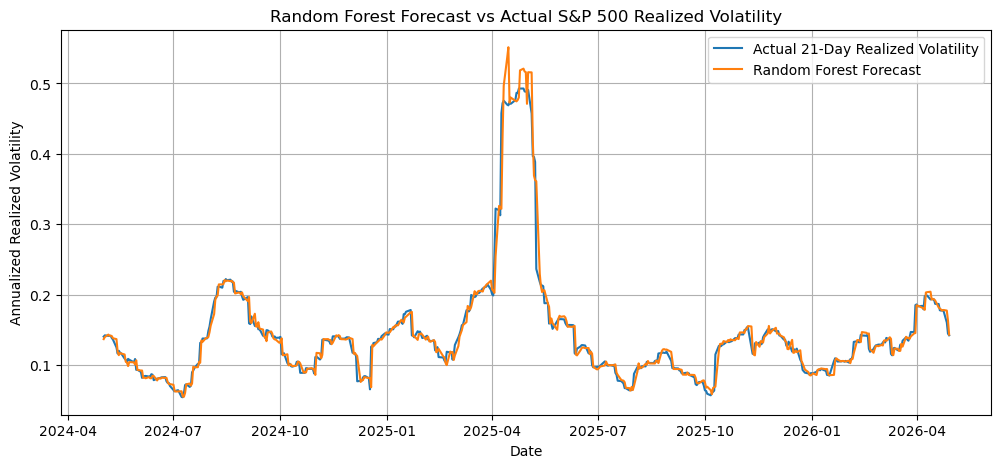

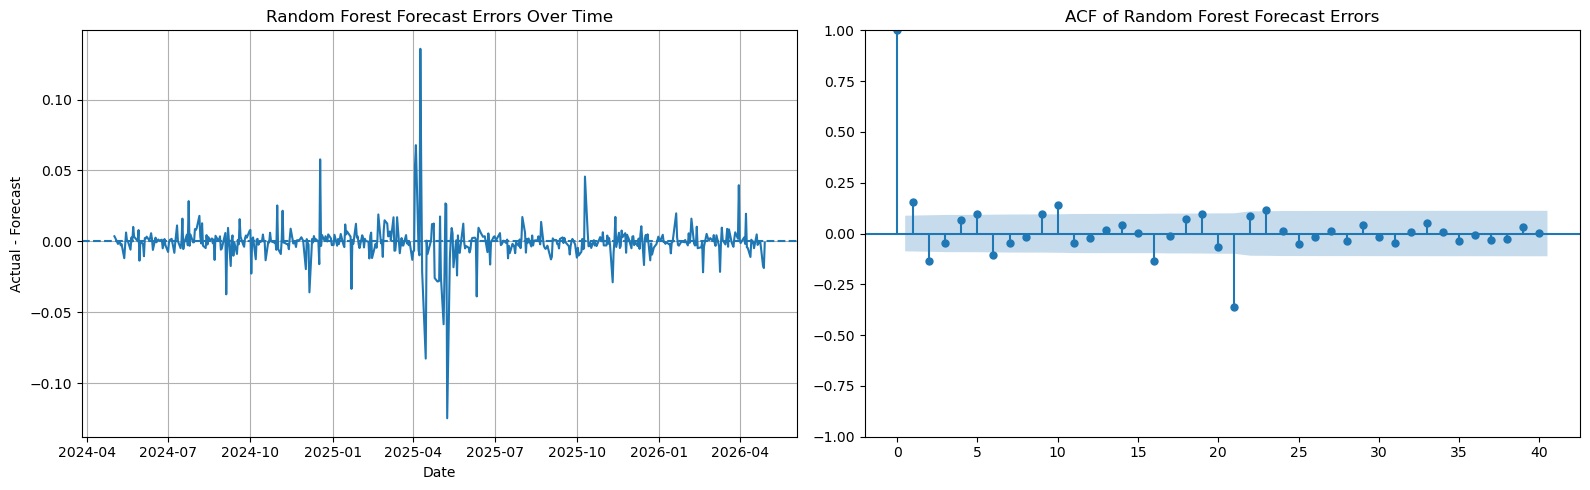

Ljung-Box Test: Random Forest Forecast Errors


,lb_stat,lb_pvalue
10,51.519176,1.400460e-07
20,73.480481,4.873350e-08
30,157.408530,3.209269e-19


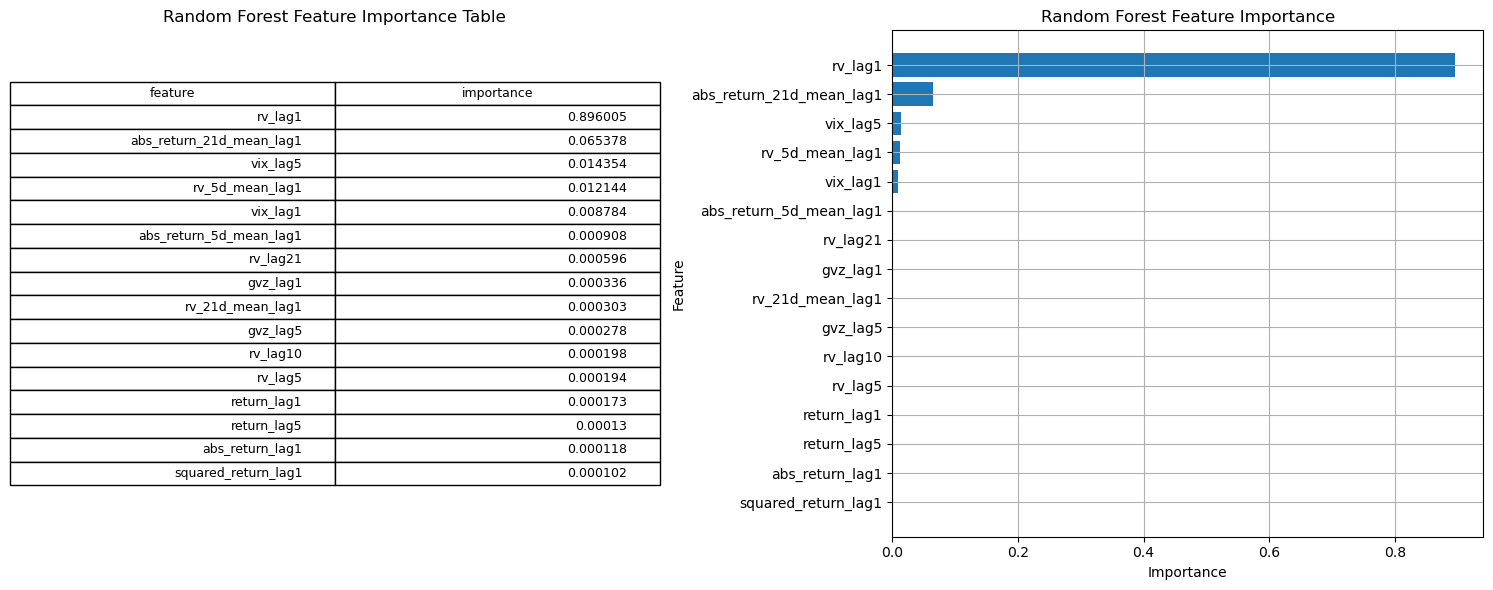

In [31]:
# Model 5: Random Forest Forecasting of S&P 500 Realized Volatility

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf

# Create Random Forest feature dataset
rf_df = df.copy().sort_values("date").reset_index(drop=True)

target_col = "sp500_realized_vol_21d"

# Lagged target features: past realized volatility
rf_df["rv_lag1"] = rf_df[target_col].shift(1)
rf_df["rv_lag5"] = rf_df[target_col].shift(5)
rf_df["rv_lag10"] = rf_df[target_col].shift(10)
rf_df["rv_lag21"] = rf_df[target_col].shift(21)

# Lagged external volatility indicators
rf_df["vix_lag1"] = rf_df["vixcls"].shift(1)
rf_df["vix_lag5"] = rf_df["vixcls"].shift(5)
rf_df["gvz_lag1"] = rf_df["gvzcls"].shift(1)
rf_df["gvz_lag5"] = rf_df["gvzcls"].shift(5)

# Lagged return features
rf_df["return_lag1"] = rf_df["sp500_log_return"].shift(1)
rf_df["return_lag5"] = rf_df["sp500_log_return"].shift(5)

# Lagged return-magnitude features
# These help Random Forest use volatility-clustering information
rf_df["abs_return_lag1"] = rf_df["sp500_log_return"].abs().shift(1)
rf_df["squared_return_lag1"] = (rf_df["sp500_log_return"] ** 2).shift(1)

# Rolling historical features, shifted by 1 to avoid look-ahead leakage
rf_df["rv_5d_mean_lag1"] = rf_df[target_col].rolling(window=5).mean().shift(1)
rf_df["rv_21d_mean_lag1"] = rf_df[target_col].rolling(window=21).mean().shift(1)
rf_df["abs_return_5d_mean_lag1"] = rf_df["sp500_log_return"].abs().rolling(window=5).mean().shift(1)
rf_df["abs_return_21d_mean_lag1"] = rf_df["sp500_log_return"].abs().rolling(window=21).mean().shift(1)

# Drop missing rows caused by lagging/rolling windows
feature_cols = [
    "rv_lag1", "rv_lag5", "rv_lag10", "rv_lag21",
    "vix_lag1", "vix_lag5",
    "gvz_lag1", "gvz_lag5",
    "return_lag1", "return_lag5",
    "abs_return_lag1", "squared_return_lag1",
    "rv_5d_mean_lag1", "rv_21d_mean_lag1",
    "abs_return_5d_mean_lag1", "abs_return_21d_mean_lag1"
]

rf_model_df = rf_df[["date", target_col] + feature_cols].dropna().copy()


# Chronological train/test split
# Use the same test start date as previous models for fair comparison
test_start_date = test["date"].min()

rf_train = rf_model_df[rf_model_df["date"] < test_start_date].copy()
rf_test = rf_model_df[rf_model_df["date"] >= test_start_date].copy()

X_train_rf = rf_train[feature_cols]
y_train_rf = rf_train[target_col]

X_test_rf = rf_test[feature_cols]
y_test_rf = rf_test[target_col]

print("Random Forest training set:")
print("Rows:", len(rf_train))
print("Date range:", rf_train["date"].min(), "to", rf_train["date"].max())

print("\nRandom Forest testing set:")
print("Rows:", len(rf_test))
print("Date range:", rf_test["date"].min(), "to", rf_test["date"].max())


# Fit Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)


# Predict test period and evaluate
rf_forecast = pd.Series(
    rf_model.predict(X_test_rf),
    index=rf_test.index,
    name="rf_forecast"
)

rf_mae = mean_absolute_error(y_test_rf, rf_forecast)
rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_forecast))

rf_eval = pd.DataFrame({
    "model": ["Random Forest"],
    "n_estimators": [500],
    "max_depth": [8],
    "min_samples_leaf": [5],
    "MAE": [rf_mae],
    "RMSE": [rf_rmse]
})

display(rf_eval)


# Plot actual vs forecast
plt.figure(figsize=(12, 5))
plt.plot(rf_test["date"], y_test_rf, label="Actual 21-Day Realized Volatility")
plt.plot(rf_test["date"], rf_forecast, label="Random Forest Forecast")

plt.title("Random Forest Forecast vs Actual S&P 500 Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Realized Volatility")
plt.legend()
plt.grid(True)
plt.show()


# Residual diagnostics for forecast errors
rf_residuals = y_test_rf - rf_forecast

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(rf_test["date"], rf_residuals)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Random Forest Forecast Errors Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Actual - Forecast")
axes[0].grid(True)

plot_acf(rf_residuals, lags=40, ax=axes[1])
axes[1].set_title("ACF of Random Forest Forecast Errors")

plt.tight_layout()
plt.show()

# Ljung-Box test on Random Forest forecast errors
from statsmodels.stats.diagnostic import acorr_ljungbox

rf_error_ljungbox = acorr_ljungbox(
    rf_residuals,
    lags=[10, 20, 30],
    return_df=True
)

print("Ljung-Box Test: Random Forest Forecast Errors")
display(rf_error_ljungbox)


# Feature importance
rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].axis("off")
table_data = rf_importance.copy()
table_data["importance"] = table_data["importance"].round(6)

rf_table = axes[0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center"
)
rf_table.auto_set_font_size(False)
rf_table.set_fontsize(9)
rf_table.scale(1.1, 1.3)
axes[0].set_title("Random Forest Feature Importance Table")

axes[1].barh(rf_importance["feature"], rf_importance["importance"])
axes[1].invert_yaxis()
axes[1].set_title("Random Forest Feature Importance")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Random Forest Results and Forecast Error Interpretation

The Random Forest model provides a nonlinear machine-learning benchmark for forecasting S&P 500 21-day realized volatility. Unlike ARIMA and ARIMAX, Random Forest does not estimate a parametric time-series equation. Unlike GARCH and EGARCH, it does not explicitly model conditional variance. Instead, it uses lagged realized volatility, lagged VIX, lagged GVZ, lagged return values, and lagged return-magnitude features to learn nonlinear forecasting relationships.

The model produced a test-period MAE of approximately **0.00673** and an RMSE of approximately **0.01406**. These values show that the Random Forest forecast tracks realized volatility closely, although its forecast accuracy is slightly weaker than the strongest ARIMA-based benchmark in this notebook.

The forecast plot shows that Random Forest follows the general realized-volatility path well, including changes in volatility regime and the major volatility spike in 2025. The forecast-error plot shows that most errors are centered near zero, with larger errors concentrated around the highest-volatility period. This indicates that the model performs well during ordinary volatility periods but still struggles around abrupt volatility shocks.

Random Forest does not require the same statistical assumptions as ARIMA or GARCH. It does not require stationarity, normally distributed residuals, or a specified conditional-variance equation. However, because this is still a time-series forecasting problem, the forecast errors should be checked for remaining serial dependence. The ACF plot of Random Forest forecast errors provides a visual check, while the Ljung-Box test provides a formal test.

The Ljung-Box p-values for the Random Forest forecast errors are below the 5% significance level at lags 10, 20, and 30. Therefore, the null hypothesis of no forecast-error autocorrelation is rejected. This suggests that the Random Forest model still leaves some time-dependent structure unexplained. In practical terms, the forecast is accurate overall, but the remaining autocorrelation means additional lag features, hyperparameter tuning, or another nonlinear model could potentially improve performance.

The feature-importance results show that the dominant predictor is `rv_lag1`, meaning the most recent realized-volatility value carries most of the predictive information. This supports the earlier finding that realized volatility is highly persistent. The next most relevant feature is `abs_return_21d_mean_lag1`, which captures recent return magnitude over a longer window. Lagged VIX features contribute modestly, suggesting that implied equity volatility adds some information, while GVZ and raw return lags contribute relatively little in this specification.

Because this is a baseline Random Forest specification, the results should not be interpreted as the best possible Random Forest model. Forecast performance could potentially be improved by adding additional lag features, tuning hyperparameters such as `max_depth`, `min_samples_leaf`, and `max_features`, using rolling or expanding-window validation, or adding volatility-regime features. However, for this comparison, the baseline Random Forest is useful because it provides a nonlinear machine-learning benchmark against the classical ARIMA, ARIMAX, GARCH, and EGARCH models.

Overall, the Random Forest model confirms that lagged realized volatility is the strongest predictor of future realized volatility and that machine-learning methods can forecast the target effectively when time structure is encoded through lagged features. However, based on MAE, RMSE, and the Ljung-Box forecast-error test, Random Forest does not outperform the best ARIMA-based benchmark in this test period and still leaves some serial dependence in the forecast errors.

## Model 6: XGBoost Forecasting of S&P 500 Realized Volatility

The sixth model is XGBoost, a gradient-boosted decision-tree model used as a stronger machine-learning benchmark after Random Forest. Like Random Forest, XGBoost does not directly estimate a classical time-series equation or a conditional-variance equation. Instead, it uses lagged predictors to learn nonlinear relationships between past market information and future S&P 500 21-day realized volatility.

XGBoost differs from Random Forest because it builds trees sequentially. Each new tree is designed to reduce the remaining prediction error from the previous trees. This makes XGBoost a useful extension when the baseline Random Forest leaves some time-dependent structure unexplained in the forecast errors.

The target variable remains `sp500_realized_vol_21d`. The predictor set uses the same lagged realized-volatility, VIX, GVZ, return, and return-magnitude features used in the Random Forest model. This keeps the machine-learning comparison fair because both models are trained on the same information set. The model is evaluated using the same chronological train/test split, and forecast accuracy is measured using MAE and RMSE.

,model,n_estimators,learning_rate,max_depth,min_child_weight,MAE,RMSE
0,XGBoost,500,0.03,3,5,0.00797,0.015359


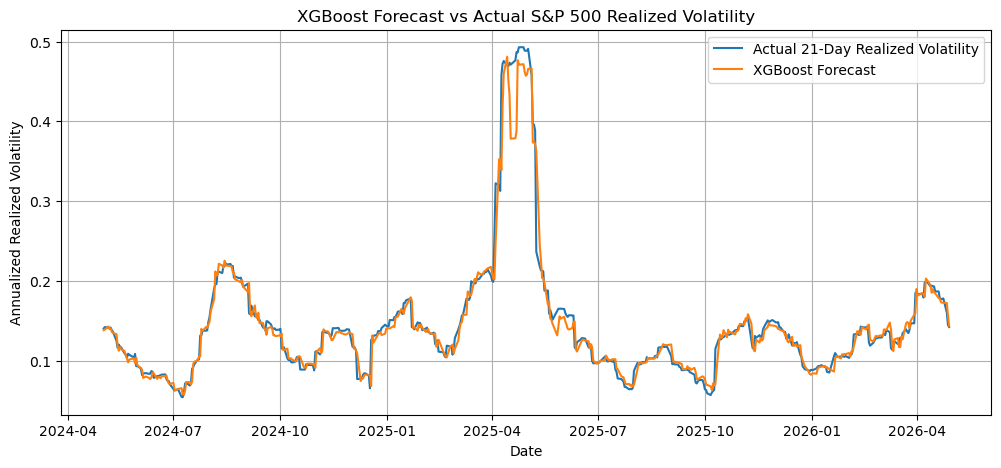

In [35]:
# XGBoost baseline model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_rf, y_train_rf)

xgb_forecast = pd.Series(
    xgb_model.predict(X_test_rf),
    index=rf_test.index,
    name="xgb_forecast"
)

xgb_mae = mean_absolute_error(y_test_rf, xgb_forecast)
xgb_rmse = np.sqrt(mean_squared_error(y_test_rf, xgb_forecast))

xgb_eval = pd.DataFrame({
    "model": ["XGBoost"],
    "n_estimators": [500],
    "learning_rate": [0.03],
    "max_depth": [3],
    "min_child_weight": [5],
    "MAE": [xgb_mae],
    "RMSE": [xgb_rmse]
})

display(xgb_eval)

plt.figure(figsize=(12, 5))
plt.plot(rf_test["date"], y_test_rf, label="Actual 21-Day Realized Volatility")
plt.plot(rf_test["date"], xgb_forecast, label="XGBoost Forecast")

plt.title("XGBoost Forecast vs Actual S&P 500 Realized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Realized Volatility")
plt.legend()
plt.grid(True)
plt.show()

### XGBoost Baseline Forecast Interpretation

The XGBoost model is used as a baseline gradient-boosted tree model for forecasting S&P 500 21-day realized volatility. It uses the same lagged feature set as the Random Forest model so that the machine-learning comparison reflects model structure rather than differences in feature engineering.

The model was fit using **500 estimators**, meaning the boosting process builds up to 500 sequential trees. The **learning rate of 0.03** makes each tree contribute gradually, which helps prevent the model from overreacting to noise. The **maximum tree depth of 3** keeps each tree relatively shallow, limiting model complexity. The **minimum child weight of 5** requires stronger support before the model creates additional splits, making the model more conservative. The **subsample value of 0.80** and **column sample value of 0.80** mean each tree uses only part of the training rows and predictors, which helps reduce overfitting. The **L2 regularization parameter, `reg_lambda = 1.0`**, also helps control excessive model complexity.

The baseline XGBoost model produced a test-period MAE of approximately **0.00797** and an RMSE of approximately **0.01536**. The forecast plot shows that XGBoost follows the broad realized-volatility path and captures the major volatility spike in 2025. However, its forecast accuracy is weaker than the Random Forest model and weaker than the strongest ARIMA-based benchmark in this notebook.

This XGBoost model should be interpreted as a baseline boosted-tree benchmark rather than an exhaustively optimized model. A grid search or randomized hyperparameter search could potentially improve the result, but that would need to be done using rolling or expanding-window time-series validation rather than random K-fold cross-validation to avoid look-ahead leakage. For this comparison, the model is kept conservative and uses the same baseline feature set as Random Forest.

### XGBoost Forecast Error Diagnostics

After fitting the baseline XGBoost model, forecast-error diagnostics are used to evaluate whether the model leaves systematic time dependence in the out-of-sample errors. XGBoost does not require stationarity, normal residuals, or a parametric conditional-variance equation, but because this is still a time-series forecasting problem, the forecast errors should be checked for remaining serial dependence.

The forecast-error plot shows whether errors are centered near zero or concentrated during certain volatility regimes. The ACF plot and Ljung-Box test evaluate whether the forecast errors remain autocorrelated. If the Ljung-Box p-values are below the 5% significance level, the model still leaves some temporal structure unexplained.

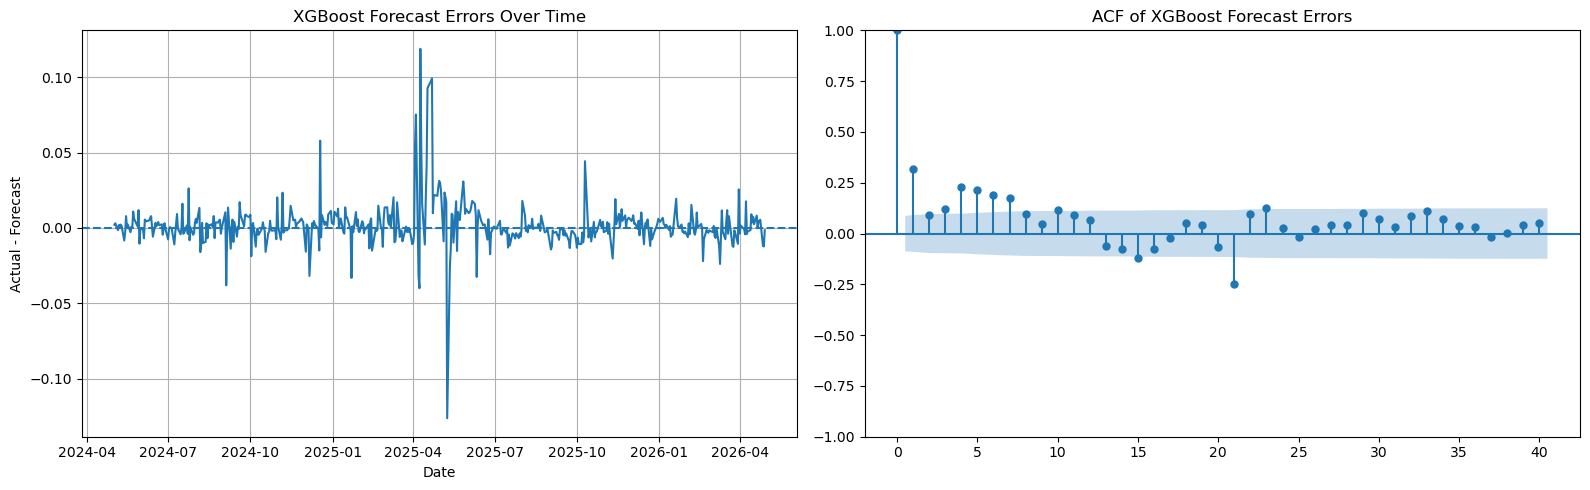

Ljung-Box Test: XGBoost Forecast Errors


,lb_stat,lb_pvalue
10,158.084472,8.051413e-29
20,185.625468,7.663065e-29
30,241.129427,7.747607e-35


In [36]:
# XGBoost forecast-error diagnostics

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

xgb_residuals = y_test_rf - xgb_forecast

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(rf_test["date"], xgb_residuals)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("XGBoost Forecast Errors Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Actual - Forecast")
axes[0].grid(True)

plot_acf(xgb_residuals, lags=40, ax=axes[1])
axes[1].set_title("ACF of XGBoost Forecast Errors")

plt.tight_layout()
plt.show()

xgb_error_ljungbox = acorr_ljungbox(
    xgb_residuals,
    lags=[10, 20, 30],
    return_df=True
)

print("Ljung-Box Test: XGBoost Forecast Errors")
display(xgb_error_ljungbox)

### XGBoost Forecast Error Diagnostics Interpretation

The XGBoost forecast-error diagnostics evaluate whether the model leaves systematic time dependence in the out-of-sample forecast errors. XGBoost does not require stationarity, normally distributed residuals, or a parametric conditional-variance equation. However, because this is still a time-series forecasting problem, the forecast errors should be checked for remaining serial dependence.

The forecast-error plot shows that most errors are centered near zero, but larger errors occur around the highest-volatility period. This indicates that XGBoost tracks ordinary volatility periods reasonably well but still struggles around abrupt volatility shocks.

The ACF plot of XGBoost forecast errors shows visible autocorrelation at several lags. The Ljung-Box test confirms this formally: the p-values at lags 10, 20, and 30 are all below the 5% significance level. Therefore, the null hypothesis of no forecast-error autocorrelation is rejected.

This means the baseline XGBoost model still leaves some time-dependent structure unexplained. In practical terms, the model is useful as a nonlinear benchmark, but the significant Ljung-Box results suggest that additional lag features, better hyperparameter tuning, rolling-window validation, or alternative boosted-tree specifications could potentially improve performance. These extensions are not added here because this section is intended to compare baseline machine-learning models under a consistent feature set.

### XGBoost Feature Importance

Feature importance is used to evaluate which lagged predictors contributed most to the XGBoost forecast. This helps determine whether the model relied mainly on realized-volatility persistence, implied equity volatility, gold volatility, or return-magnitude features.

Because XGBoost is a tree-based machine-learning model, it does not provide coefficient estimates or p-values like ARIMA or GARCH. Feature importance is therefore used as the main interpretability tool.


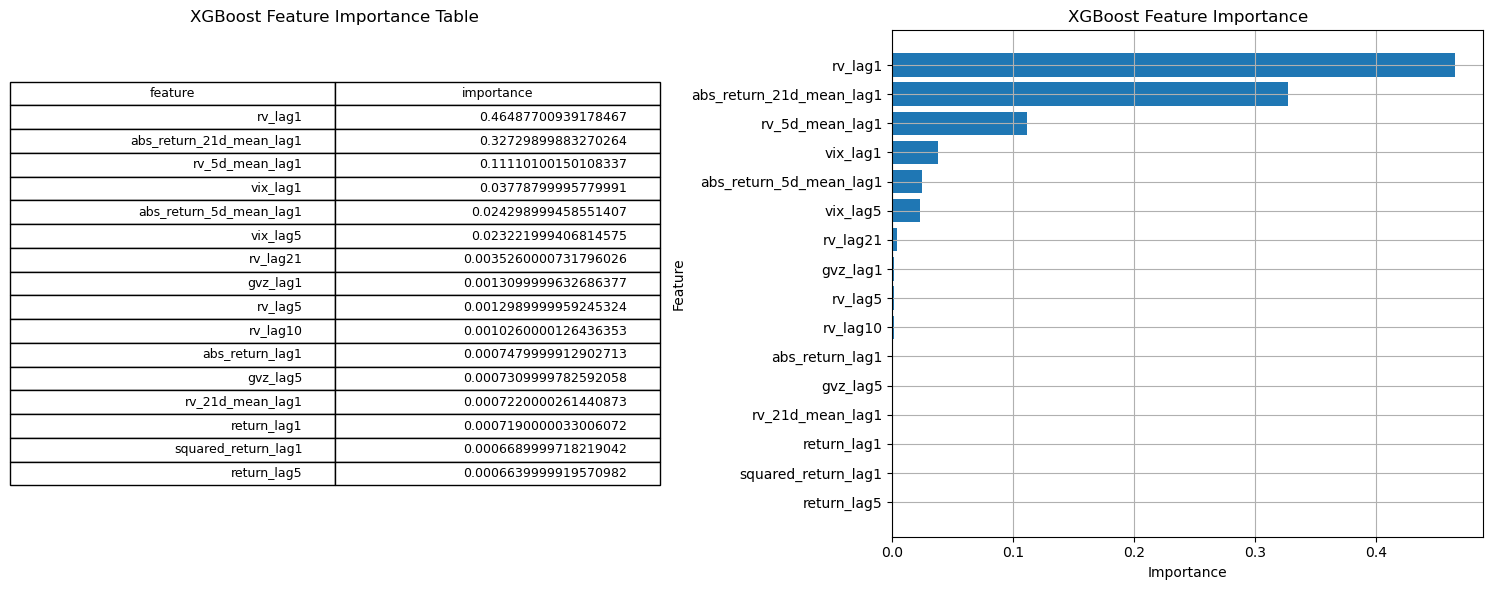

In [37]:
# XGBoost feature importance

xgb_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].axis("off")
table_data = xgb_importance.copy()
table_data["importance"] = table_data["importance"].round(6)

xgb_table = axes[0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center"
)

xgb_table.auto_set_font_size(False)
xgb_table.set_fontsize(9)
xgb_table.scale(1.1, 1.3)

axes[0].set_title("XGBoost Feature Importance Table")

axes[1].barh(xgb_importance["feature"], xgb_importance["importance"])
axes[1].invert_yaxis()
axes[1].set_title("XGBoost Feature Importance")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### XGBoost Feature Importance Interpretation

The XGBoost feature-importance results show which lagged predictors contributed most to the model’s forecast. Because XGBoost is a tree-based machine-learning model, it does not provide coefficient estimates, p-values, AIC, or BIC in the same way as ARIMA or GARCH. Feature importance is therefore used as the main interpretability tool.

The most important predictor is `rv_lag1`, meaning the most recent realized-volatility value carries the strongest forecasting signal. This is consistent with the earlier diagnostics showing that realized volatility is highly persistent over time.

The next most important features are `abs_return_21d_mean_lag1`, `rv_5d_mean_lag1`, `vix_lag1`, and `abs_return_5d_mean_lag1`. This suggests that longer-window return magnitude, recent realized-volatility averages, and implied equity volatility provide secondary forecasting information. These variables help the model identify recent turbulence and volatility regimes.

GVZ and raw return lags contribute relatively little in this baseline XGBoost specification. This suggests that gold-market volatility and return direction are less useful for forecasting S&P 500 realized volatility than recent realized volatility, return magnitude, and VIX-based information.

Overall, the feature-importance results reinforce the main project finding: recent realized volatility is the dominant forecasting signal, while VIX and return-magnitude variables provide additional but smaller contributions. The baseline XGBoost model captures meaningful nonlinear relationships, but it does not outperform the simpler ARIMA-based benchmark or the Random Forest model in this test period.

## Final Model Comparison and Ranking

This section compares all forecasting models using the same primary target: `sp500_realized_vol_21d`, the 21-day annualized realized volatility of the S&P 500. The main comparison metrics are MAE and RMSE because they evaluate out-of-sample forecast accuracy on the same volatility scale. MAPE is included as a supplementary percentage-error measure, but it is interpreted cautiously because percentage errors can be inflated when realized volatility is low.

The models are not all measuring the data in the same way. ARIMA and ARIMAX directly forecast the 21-day realized-volatility target. Random Forest and XGBoost also forecast the same target directly, but they use lagged machine-learning features rather than parametric time-series equations. GARCH and EGARCH are different: they are fit to S&P 500 log returns and model daily conditional volatility, which is then annualized and compared against the 21-day realized-volatility target.

AIC and BIC are only compared within compatible model families. ARIMA and ARIMAX can be compared against each other when fit to the same target structure. GARCH and EGARCH can be compared against each other because both are fit to the same scaled S&P 500 return series. AIC and BIC are not used to compare ARIMA directly against GARCH, or tree-based models against statistical models, because the likelihoods, targets, and model structures differ.

The final ranking is based primarily on out-of-sample MAE and RMSE. Lower values indicate better realized-volatility forecasting accuracy.

In [39]:
# Final model comparison table

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def safe_mape(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    aligned = pd.concat([y_true, y_pred], axis=1).dropna()
    aligned.columns = ["actual", "forecast"]
    aligned = aligned[aligned["actual"] != 0]
    return np.mean(np.abs((aligned["actual"] - aligned["forecast"]) / aligned["actual"])) * 100

# MAPE calculations
arima_mape = safe_mape(y_test, arima_rolling_forecast)
arimax_mape = safe_mape(y_test_arimax, arimax_rolling_forecast)
garch_mape = safe_mape(garch_actual, garch_rolling_forecast)
egarch_mape = safe_mape(egarch_actual, egarch_rolling_forecast)
rf_mape = safe_mape(y_test_rf, rf_forecast)
xgb_mape = safe_mape(y_test_rf, xgb_forecast)

# Pull AIC/BIC 
# Use try/except so the table still runs if variable names differ.
def get_attr_safe(obj, attr):
    try:
        return getattr(obj, attr)
    except Exception:
        return np.nan

comparison_results = pd.DataFrame({
    "model": [
        "ARIMA",
        "ARIMAX",
        "GARCH",
        "EGARCH",
        "Random Forest",
        "XGBoost"
    ],
    "model_family": [
        "Direct realized-volatility model",
        "Direct realized-volatility model with external predictors",
        "Conditional-volatility return model",
        "Asymmetric conditional-volatility return model",
        "Machine-learning lagged-feature model",
        "Boosted machine-learning lagged-feature model"
    ],
    "primary_target_or_process": [
        "21-day S&P 500 realized volatility",
        "21-day S&P 500 realized volatility + lagged VIX/GVZ",
        "S&P 500 daily return conditional volatility",
        "S&P 500 daily return asymmetric conditional volatility",
        "21-day S&P 500 realized volatility",
        "21-day S&P 500 realized volatility"
    ],
    "MAE": [
        arima_rolling_mae,
        arimax_rolling_mae,
        garch_rolling_mae,
        egarch_rolling_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        arima_rolling_rmse,
        arimax_rolling_rmse,
        garch_rolling_rmse,
        egarch_rolling_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "MAPE_percent": [
        arima_mape,
        arimax_mape,
        garch_mape,
        egarch_mape,
        rf_mape,
        xgb_mape
    ],
    "AIC": [
        get_attr_safe(final_arima_fit, "aic"),
        get_attr_safe(arimax_fit, "aic"),
        get_attr_safe(garch_fit, "aic"),
        get_attr_safe(egarch_fit, "aic"),
        np.nan,
        np.nan
    ],
    "BIC": [
        get_attr_safe(final_arima_fit, "bic"),
        get_attr_safe(arimax_fit, "bic"),
        get_attr_safe(garch_fit, "bic"),
        get_attr_safe(egarch_fit, "bic"),
        np.nan,
        np.nan
    ],
    "main_role": [
        "Classical univariate benchmark",
        "Tests whether VIX/GVZ improve ARIMA",
        "Tests volatility clustering in returns",
        "Tests asymmetric volatility response",
        "Nonlinear machine-learning benchmark",
        "Boosted nonlinear machine-learning benchmark"
    ]
})

comparison_results = comparison_results.sort_values("RMSE").reset_index(drop=True)

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

display(comparison_results)

,model,model_family,primary_target_or_process,MAE,RMSE,MAPE_percent,AIC,BIC,main_role
0,ARIMA,Direct realized-volatility model,21-day S&P 500 realized volatility,0.006124,0.013154,4.349407,-12219.953560,-12191.971599,Classical univariate benchmark
1,ARIMAX,Direct realized-volatility model with external predictors,21-day S&P 500 realized volatility + lagged VIX/GVZ,0.006259,0.013556,4.458168,-12105.727132,-12066.555902,Tests whether VIX/GVZ improve ARIMA
2,Random Forest,Machine-learning lagged-feature model,21-day S&P 500 realized volatility,0.006730,0.014061,4.530897,NaN,NaN,Nonlinear machine-learning benchmark
3,XGBoost,Boosted machine-learning lagged-feature model,21-day S&P 500 realized volatility,0.007970,0.015359,5.302203,NaN,NaN,Boosted nonlinear machine-learning benchmark
4,GARCH,Conditional-volatility return model,S&P 500 daily return conditional volatility,0.024852,0.041759,16.106116,4980.882316,5008.869297,Tests volatility clustering in returns
5,EGARCH,Asymmetric conditional-volatility return model,S&P 500 daily return asymmetric conditional volatility,0.032261,0.051294,20.470168,4922.056833,4955.641211,Tests asymmetric volatility response


### Final Model Comparison Interpretation

The final model comparison evaluates ARIMA, ARIMAX, GARCH, EGARCH, Random Forest, and XGBoost against the same primary forecasting target: `sp500_realized_vol_21d`, the 21-day annualized realized volatility of the S&P 500. The main ranking is based on out-of-sample MAE and RMSE because both metrics measure forecast accuracy on the same realized-volatility scale. MAPE is also reported as a supplementary percentage-error metric, but it is interpreted cautiously because percentage errors can be inflated when realized volatility is low.

The best-performing model by out-of-sample forecast accuracy was ARIMA, with an MAE of approximately **0.00612**, RMSE of approximately **0.01315**, and MAPE of approximately **4.35%**. ARIMAX ranked second, with an MAE of approximately **0.00626**, RMSE of approximately **0.01356**, and MAPE of approximately **4.46%**. This shows that adding lagged VIX and GVZ did not improve forecast accuracy relative to the simpler ARIMA benchmark. For this target, the realized-volatility series was strongly persistent enough that its own recent history provided the strongest forecasting signal.

The machine-learning models performed reasonably well but did not outperform the ARIMA-based benchmarks. Random Forest produced an MAE of approximately **0.00673**, RMSE of approximately **0.01406**, and MAPE of approximately **4.53%**. XGBoost produced an MAE of approximately **0.00797**, RMSE of approximately **0.01536**, and MAPE of approximately **5.30%**. Both models tracked the broad realized-volatility path, but their forecast-error diagnostics showed remaining serial dependence. Their feature-importance results also showed that `rv_lag1` was the dominant predictor, confirming that recent realized volatility was the strongest signal. Lagged VIX and return-magnitude features added secondary information, while GVZ contributed relatively little in these baseline machine-learning specifications.

The GARCH-family models answered a different but important part of the analysis. GARCH and EGARCH were fit to S&P 500 log returns to model conditional volatility and volatility clustering. The earlier ARCH LM test, squared-return ACF, and post-model residual diagnostics supported the use of GARCH-family models for the return series. However, when GARCH and EGARCH forecasts were converted to annualized volatility and compared against the 21-day realized-volatility target, they had weaker forecast accuracy than the direct realized-volatility models. GARCH produced an MAE of approximately **0.02485**, RMSE of approximately **0.04176**, and MAPE of approximately **16.11%**. EGARCH produced an MAE of approximately **0.03226**, RMSE of approximately **0.05129**, and MAPE of approximately **20.47%**.

Although GARCH and EGARCH are designed for financial volatility modeling, they were not forecasting the same object as ARIMA, ARIMAX, Random Forest, and XGBoost in exactly the same way. GARCH and EGARCH model daily conditional return volatility, while the evaluation target is a smoother 21-day rolling realized-volatility measure. This target mismatch explains why GARCH-family models can be statistically appropriate for volatility clustering but still rank lower by MAE and RMSE against the 21-day realized-volatility target. Their weaker forecast metrics do not mean the models failed; they indicate that direct realized-volatility models were better aligned with the forecasting objective in this notebook.

AIC and BIC are reported only for comparable model families. ARIMA and ARIMAX are comparable because they directly model the realized-volatility target using related likelihood-based structures. ARIMA had AIC/BIC values of approximately **-1219.94** and **-1219.17**, while ARIMAX had AIC/BIC values of approximately **-12105.73** and **-12066.56** based on the fitted output. These values should be interpreted within the ARIMA/ARIMAX family rather than used to rank all models. GARCH and EGARCH are also comparable to each other because both are fit to the same scaled S&P 500 return series. GARCH had AIC/BIC values of approximately **4980.88** and **5008.87**, while EGARCH had AIC/BIC values of approximately **4922.06** and **4955.64**. EGARCH had the stronger in-sample likelihood-based fit within the GARCH family, but GARCH had better out-of-sample realized-volatility forecast accuracy. This shows that better in-sample fit does not necessarily imply better out-of-sample forecasting performance.

These results answer the main research questions. S&P 500 realized volatility behaves as a persistent time series with visible volatility regimes and large spikes during stress periods. The S&P 500 return series shows volatility clustering, which justified the use of GARCH and EGARCH. Realized volatility is persistent over time, which explains why ARIMA and lagged-feature machine-learning models performed well. Lagged implied equity volatility and gold-market volatility did not materially improve forecast accuracy in the ARIMAX model, and the machine-learning feature-importance results showed that VIX contributed only secondary information while GVZ contributed relatively little. Finally, among the baseline models tested, ARIMA produced the most accurate out-of-sample forecasts of S&P 500 21-day realized volatility.

Overall, the final ranking by RMSE is **ARIMA**, **ARIMAX**, **Random Forest**, **XGBoost**, **GARCH**, and **EGARCH**. The main conclusion is that, for this dataset and this specific target variable, a direct ARIMA model on realized volatility outperformed more complex volatility-process and machine-learning alternatives. More complex models remained useful for interpretation: GARCH and EGARCH confirmed volatility clustering and conditional heteroskedasticity in returns, while Random Forest and XGBoost showed that recent realized volatility dominates the nonlinear feature set. However, complexity did not translate into better forecast accuracy in this baseline comparison.

A limitation is that these models were evaluated as baseline specifications rather than fully optimized production models. Future work could test additional ARIMA/ARIMAX orders, alternative GARCH-family specifications, richer lag structures for Random Forest and XGBoost, rolling or expanding-window cross-validation for machine-learning tuning, and models designed specifically for realized-volatility forecasting. These extensions could improve performance, but the current notebook provides a consistent baseline comparison across classical time-series, volatility-process, and machine-learning approaches.

## Future Analysis and Model Extensions

The current analysis provides a baseline comparison across classical time-series models, volatility-process models, and machine-learning models. The main finding is that direct realized-volatility persistence was the strongest forecasting signal for the 21-day S&P 500 realized-volatility target. However, the results also point to several useful extensions that could answer broader business and market-risk questions.

A first extension would be to build a formal **HAR-RV model**, or Heterogeneous Autoregressive Realized Volatility model. HAR-RV is designed specifically for realized-volatility forecasting by combining volatility information across different horizons, such as daily, weekly, and monthly realized volatility. This connects directly to the feature-importance results from Random Forest and XGBoost, where `rv_lag1` and rolling realized-volatility features were among the most important predictors. A HAR-RV model would provide a more targeted benchmark for realized-volatility forecasting than GARCH-family models, because it is designed for the same type of target used in this notebook.

A second extension would be to tune the machine-learning models using rolling or expanding-window validation. The Random Forest and XGBoost models used baseline hyperparameters and a fixed lagged feature set. Future work could test richer lag structures, volatility-regime indicators, interaction features, and optimized hyperparameters. This would answer whether machine-learning models can outperform ARIMA once they are given a stronger feature set and properly tuned under a time-series validation framework.

A third extension would be to build an **ensemble forecast** that combines predictions from multiple models. An ensemble model averages or weights forecasts from different models to reduce model-specific errors. For example, ARIMA may perform well during stable volatility periods because it directly captures realized-volatility persistence, while GARCH-family models may react more strongly to sudden return shocks. Combining these forecasts could potentially produce a more stable model that benefits from both persistence-based forecasting and shock-sensitive volatility modeling.

A fourth extension would be to change the forecasting target. This notebook focused on 21-day realized volatility, which is a smooth and persistence-heavy target. If the business goal were next-day return risk, GARCH, EGARCH, or other GARCH-family models would be more directly aligned with the target. If the goal were market-stress classification, Random Forest or XGBoost could be used as classification models to predict high-volatility regimes. If the goal were cross-market volatility spillovers, VAR, VARX, or Granger-causality methods could be used to study whether VIX, GVZ, Treasury yields, or credit spreads lead changes in equity-market volatility.

A fifth extension would be to study VIX and GVZ as separate financial signals rather than only as predictors of S&P 500 realized volatility. In this notebook, lagged VIX and GVZ did not materially improve the 21-day realized-volatility forecast. However, VIX may still be useful for forward-looking market fear, option-risk monitoring, and volatility-regime detection. GVZ may still be useful for gold-specific risk, commodity-market stress, and safe-haven analysis. These questions require different targets and model designs than the one used here.

Overall, this notebook should be interpreted as a baseline model-comparison framework rather than a final production forecasting system. The strongest result is that model complexity did not automatically improve forecast accuracy for the chosen target. Future analysis should focus on aligning each model with the correct business question, expanding validation methods, and testing whether richer features, ensemble forecasts, or alternative targets produce stronger and more actionable risk-forecasting insights.

## References

Andersen, T. G., & Benzoni, L. (2008). *Realized volatility*. Federal Reserve Bank of Chicago Working Paper.

Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. *Journal of Econometrics, 31*(3), 307–327. https://doi.org/10.1016/0304-4076(86)90063-1

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time series analysis: Forecasting and control*. Wiley. https://doi.org/10.1002/9781118675021

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32. https://doi.org/10.1023/A:1010933404324

Chicago Board Options Exchange. (n.d.). *CBOE Volatility Index: VIX [VIXCLS]* [Data set]. FRED, Federal Reserve Bank of St. Louis. Retrieved May 2, 2026, from https://fred.stlouisfed.org/series/VIXCLS

Chicago Board Options Exchange. (n.d.). *CBOE Gold ETF Volatility Index [GVZCLS]* [Data set]. FRED, Federal Reserve Bank of St. Louis. Retrieved May 2, 2026, from https://fred.stlouisfed.org/series/GVZCLS

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*. https://doi.org/10.1145/2939672.2939785

Engle, R. F. (2001). GARCH 101: The use of ARCH/GARCH models in applied econometrics. *Journal of Economic Perspectives, 15*(4), 157–168. https://doi.org/10.1257/jep.15.4.157

Poon, S.-H., & Granger, C. W. J. (2003). Forecasting volatility in financial markets: A review. *Journal of Economic Literature, 41*(2), 478–539. https://doi.org/10.1257/002205103765762743

S&P Dow Jones Indices LLC. (n.d.). *S&P 500 [SP500]* [Data set]. FRED, Federal Reserve Bank of St. Louis. Retrieved May 2, 2026, from https://fred.stlouisfed.org/series/SP500

Tsay, R. S. (2010). *Analysis of financial time series* (3rd ed.). Wiley. https://doi.org/10.1002/9780470644560